# BPH-7009 — Analyse de signaux — Devoir 2

<a id="0"></a>
## 0. Préambule

### 0.1 Imports et style

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from scipy.special import erf
from scipy.optimize import curve_fit

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#86b6ef", "#70a8eb", "#599be8", "#458ce1", "#327ed9", "#2974d0",
       "#266ec5", "#2365b7", "#1d59a4", "#174d91", "#12417e", "#0d366b"]
GRIS = "#52514e"

def seq(k):
    """
    k couleurs ordonnées, du bleu clair au bleu foncé.
    """

    indices = np.linspace(0, len(SEQ) - 1, k).round().astype(int)
    
    return [SEQ[i] for i in indices]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRIS,
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": True,
    "legend.fontsize": 8,
    "lines.linewidth": 2,
    "lines.markersize": 4,
    "image.cmap": "magma",
    "figure.autolayout": True,
})


### 0.2 Géométries

Toutes les parois sont réfléchissantes.

In [2]:
def _reflechir(x, a, b):
    """
    Replie x dans [a, b] par réflexions successives.
    """

    p = 2*(b - a)
    y = np.mod(x - a, p)

    return a + np.where(y > b - a, p - y, y)


class Plan:
    """
    Plan libre, sans paroi. L ne fixe que l'étendue du tirage initial.
    exact = True : le repliement peut s'appliquer d'un coup au chemin non replié,
    ce qui autorise une simulation par blocs vectorisés plutôt qu'en boucle.
    """

    exact = True

    def __init__(self, L=10.0):
        self.L = L

    def tirage(self, rng, n):
        return rng.uniform(-self.L/2, self.L/2, (n, 2))

    def replier(self, r):
        return r

    def limites(self, r, r0):
        return self.replier(r)


class Boite(Plan):
    """
    Boîte carrée L x L à parois réfléchissantes.
    """

    def replier(self, r):
        x = _reflechir(r[..., 0], -self.L/2, self.L/2)
        y = _reflechir(r[..., 1], -self.L/2, self.L/2)

        return np.stack([x, y], -1)


class Disque:
    """
    Confinement circulaire de rayon R.
    """

    exact = False

    def __init__(self, R):
        self.R = R

    def tirage(self, rng, n):
        th = rng.uniform(0, 2*np.pi, n)
        u = np.sqrt(rng.uniform(size=n))

        return self.R*np.stack([u*np.cos(th), u*np.sin(th)], 1)

    def limites(self, r, r0):
        d = np.hypot(r[:, 0], r[:, 1])
        facteur = np.where(d > self.R, (2*self.R - d)/np.maximum(d, 1e-12), 1.0)

        return r*facteur[:, None]


class Tube:
    """
    Tube de diamètre d orienté selon x. L=None : longueur infinie.
    """

    exact = True

    def __init__(self, d, L=None):
        self.d = d
        self.L = L

    def tirage(self, rng, n):
        if self.L:
            Lx = self.L
        else:
            Lx = self.d

        x = rng.uniform(-Lx/2, Lx/2, n)
        y = rng.uniform(-self.d/2, self.d/2, n)

        return np.stack([x, y], 1)

    def replier(self, r):
        if self.L:
            x = _reflechir(r[..., 0], -self.L/2, self.L/2)
        else:
            x = r[..., 0]

        y = _reflechir(r[..., 1], -self.d/2, self.d/2)

        return np.stack([x, y], -1)

    def limites(self, r, r0):
        return self.replier(r)


### 0.3 Simulateur de trajectoires

Marche aléatoire gaussienne : $\Delta \mathbf{r} \sim \mathcal{N}(0,\ 2D\,\Delta t)$ par axe.
L'argument `mesure` permet de ne conserver qu'une observable (intensité, comptage) au lieu de
toutes les positions, ce qui rend possibles les très longues simulations de FCS.

In [3]:
def simuler(dom, D, T, dt, n=1, f_immobile=0.0, seed=0, mesure=None, bloc=None):
    """
    n trajectoires browniennes 2D dans le domaine `dom`.

    D : coefficient de diffusion (um^2/s)
    T, dt : durée et pas de temps (s)
    f_immobile : fraction de particules fixes
    mesure : fonction appliquée à un bloc de positions (nb,n,2) -> (nb,...) ;
             si fournie, seules ces valeurs sont conservees
    Retour : t (nt,) et positions (nt,n,2) ou mesures (nt,...)

    Les domaines `exact` sont simulés par blocs vectorisés (somme cumulée des pas
    puis repliement).
    """

    rng = np.random.default_rng(seed)
    nt = int(round(T/dt)) + 1
    mobile = np.arange(n) >= round(f_immobile*n)
    mobile = mobile.astype(float)[:, None]
    pas = np.sqrt(2*D*dt)*mobile
    r = dom.tirage(rng, n)
    u = r.copy()
    sortie = []
    k0 = 0
    bloc = bloc or max(4, int(1e6/n))

    while k0 < nt:
        nb = min(bloc, nt - k0)

        if dom.exact:
            d = pas*rng.standard_normal((nb, n, 2))

            if k0 == 0:
                d[0] = 0.

            np.cumsum(d, 0, out=d)
            d += u
            u = d[-1].copy()
            B = dom.replier(d)
        else:
            B = np.empty((nb, n, 2))

            for j in range(nb):
                if k0 or j:
                    r = dom.limites(r + pas*rng.standard_normal((n, 2)), r)
                B[j] = r

        if mesure is None:
            sortie.append(B)
        else:
            sortie.append(mesure(B))

        k0 += nb

    return np.arange(nt)*dt, np.concatenate(sortie)


def bruit_localisation(R, sigma, seed=1):
    """
    Erreur de localisation : bruit blanc gaussien ajouté à chaque position mesurée.
    """

    return R + np.random.default_rng(seed).normal(0., sigma, R.shape)


### 0.4 Déplacement carré moyen

Estimateur de Michalet (2010) qui utilise tous les déplacements de durée $n\Delta t$ :

$$\overline{\rho}_n = \frac{1}{N_p-n}\sum_{i=1}^{N_p-n}(\vec r_{i+n}-\vec r_i)^2
\tag{M7}$$

où $N_p$ est le nombre de positions de la trajectoire. En présence d'une erreur de localisation
$\sigma$, la courbe s'écrit

$$\rho(t) = \underbrace{4\sigma^2 - \tfrac{4}{3}D\,t_E}_{\text{ordonnée à l'origine } a}
+ \underbrace{4D}_{b}\,t
\tag{M14-15}$$

où $t_E$ est le temps d'exposition de la caméra. Les positions simulées ici sont instantanées
($t_E = 0$), donc $a = 4\sigma^2$. L'ajustement linéaire $\rho = a + bt$ donne

$$D = \frac{b}{4}, \qquad \sigma = \frac{1}{2}\sqrt{a}
\tag{M17-18}$$

Il existe un nombre optimal de points à ajuster, fonction de l'erreur de localisation réduite
$x_\sigma = \sigma^2/(D\Delta t)$ (éq. 20 de l'article), où $E$ désigne la partie entière :

$$p_{\min} = E\!\left(2 + 2{,}7\,x_\sigma^{1/2}\right)
\tag{M30}$$

Si le nombre de points est mal choisi, le $D$ ajusté peut être faux de plusieurs ordres de grandeur.
Comme $x_\sigma$ dépend du résultat, `ajuste_msd` part de $p = 2$ et itère. L'ajustement non pondéré
utilisé ici donne le même $p_{\min}$ et la même erreur minimale que l'ajustement pondéré
(section VI B de l'article).

Les numéros **M**$n$ renvoient aux équations de Michalet (2010), **Y**$n$ à celles de Yu *et al.*
(2021). Les équations sans préfixe sont posées ou dérivées ici.

In [4]:
def msd(R, dt, n_lags=35, frac=0.25, axe=None, par_particule=False):
    """
    MSD(tau). axe=None -> 2D ; axe=0 ou 1 -> une seule dimension.
    frac : décalage maximal, en fraction de la durée totale.
    """

    nt = R.shape[0]
    lag_max = max(2, int(frac*nt))
    lags = np.unique(np.logspace(0, np.log10(lag_max), n_lags).astype(int))

    if axe is None:
        X = R
    else:
        X = R[:, :, axe:axe+1]

    m = np.array([((X[l:] - X[:-l])**2).sum(-1).mean(0) for l in lags])

    if par_particule:
        return lags*dt, m

    return lags*dt, m.mean(1)


def ajuste_msd(tau, m, ndim=2, npts=None):
    """
    Régression linéaire MSD = a + b*tau -> (D, sigma)  [Michalet 2010, éq. 16-18].

    npts=None : le nombre de points suit la règle du nombre optimal
    p_min = E(2 + 2.7 sqrt(x)) (éq. 30), avec x = sigma^2/(D dt) (éq. 20) l'erreur de
    localisation réduite. x dépendant du résultat, on part de p = 2 et on itère.
    """

    dt = tau[0]
    p = npts or 2

    if npts:
        n_iter = 1
    else:
        n_iter = 6

    for _ in range(n_iter):
        b, a = np.polyfit(tau[:p], m[:p], 1)   # pente b, ordonnée à l'origine a
        D, s2 = b/(2*ndim), max(a, 0.)/(2*ndim)

        if npts or D <= 0:
            break

        q = min(int(2 + 2.7*np.sqrt(s2/(D*dt))), len(tau))

        if q == p:
            break

        p = q

    return D, np.sqrt(s2)


def plateau(tau, m, frac=0.4):
    """
    Valeur du plateau de MSD (médiane sur les grands décalages).
    """

    return np.median(m[tau >= frac*tau.max()])


### 0.5 Caméra

Chaque molécule dépose `photons` photons répartis par la PSF gaussienne d'écart-type $s_0$,
intégrée sur la surface de chaque pixel (fonctions erreur), puis on ajoute un fond constant et
un tirage poissonien.

Michalet (2010) donne l'incertitude de localisation d'une molécule isolée à partir du nombre
$N_{ph}$ de photons collectés, puis sa correction lorsque la molécule diffuse pendant le temps de
pose $t_E$ :

$$\sigma_0 = \frac{s_0}{\sqrt{N_{ph}}}
\tag{M2}$$

$$\sigma = \sigma_0\sqrt{1 + \frac{D\,t_E}{s_0^2}}
\tag{M4}$$

$\sigma_0$ est l'incertitude statique et $\sigma$ l'incertitude dynamique. Ce sont des bornes
inférieures : ni le bruit de lecture ni la pixellisation ne sont pris en compte.

In [5]:
class Camera:
    """
    Détecteur : PSF gaussienne, pixels carrés, fond et bruit de Poisson.
    """

    def __init__(self, pixel=0.1, psf=0.13, champ=4.0, photons=600, fond=10):
        self.pixel = pixel
        self.psf = psf
        self.champ = champ
        self.photons = photons
        self.fond = fond
        self.npix = int(round(champ/pixel))
        self.bords = -champ/2 + np.arange(self.npix + 1)*pixel

    def _profil(self, c):
        """
        Fraction de photons de chaque molécule tombant dans chaque pixel (1 axe).
        """

        z = (self.bords[None, :] - c[:, None])/(np.sqrt(2)*self.psf)

        return 0.5*np.diff(erf(z), axis=1)

    def image(self, r, rng=None):
        profil_x = self._profil(r[:, 0])
        profil_y = self._profil(r[:, 1])
        img = self.photons*(profil_y.T @ profil_x) + self.fond
        rng = rng or np.random.default_rng(0)

        return rng.poisson(img).astype(float)

    def film(self, R, seed=0):
        rng = np.random.default_rng(seed)

        return np.array([self.image(r, rng) for r in R])

    def precision(self):
        """
        Incertitude de localisation statique sigma_0 = s_0/sqrt(N), um
        [Michalet 2010, eq. 2].
        """

        return self.psf/np.sqrt(self.photons)

    def precision_dynamique(self, D, t_expo):
        """
        Incertitude en présence de diffusion pendant l'exposition [Michalet 2010, eq. 4].
        """

        return self.precision()*np.sqrt(1 + D*t_expo/self.psf**2)


### 0.6 Laser gaussien et autocorrélation

Le faisceau est gaussien, centré en $\mathbf c$, de rayon $w_0$ à $1/e^2$. Le profil d'excitation,
normalisé au centre :

$$I(\mathbf r) = \exp\!\left(-\,\frac{2\,|\mathbf r - \mathbf c|^2}{w_0^2}\right)$$

La densité est exprimée en émetteurs par surface effective $\pi w_0^2$, ce qui donne
directement $G(0) = 1/N$.

Yu *et al.* (2021) définissent l'autocorrélation

$$G(\tau) = \frac{\langle F(t)F(t+\tau)\rangle}{\langle F(t)\rangle^2} - 1
\tag{Y1}$$

puis son modèle de diffusion, pour un volume d'observation d'extension axiale $z_0$ :

$$G(\tau) = \frac{1}{N}\left(1+\frac{\tau}{\tau_D}\right)^{-1}
\left(1+\frac{\tau}{\tau_D}\frac{w_0^2}{z_0^2}\right)^{-1/2}
\tag{Y2}$$

L'article note ce rayon $r_0$ ; on garde $w_0$ ici pour rester cohérent avec l'énoncé et avec le
code. En 2D, c'est-à-dire pour une diffusion dans une membrane, il suffit de poser $w_0/z_0 = 0$
dans (Y2), ce qui laisse

$$G(\tau) = \frac{G_0}{1+\tau/\tau_D},
\qquad G_0 = \frac{1}{N},
\qquad \tau_D = \frac{w_0^2}{4D}$$

d'où $D = w_0^2/(4\tau_D)$. La moyenne par intervalles logarithmiques de `correlation`
reproduit l'algorithme multi-tau des corrélateurs décrits dans l'article.

`fcs` enchaîne les deux étapes, de la trajectoire à $G(\tau)$. Le signal corrélé est l'intensité
collectée, sans bruit de détection : $G$ est invariante d'échelle, donc **la brillance du
fluorophore n'a aucun effet** tant qu'aucun bruit n'est ajouté. Elle n'est pas un paramètre du
simulateur. Le bruit de détection est traité séparément à la partie D, où il est ajouté
directement sur la corrélation par `bruit_blanc`.

In [6]:
class Faisceau:
    """
    Laser gaussien : renvoie la somme des intensités vues par les molécules.
    """

    def __init__(self, w0=0.2, centre=(0., 0.)):
        self.w0 = w0
        self.centre = np.asarray(centre, float)

    def __call__(self, r):
        d2 = ((r - self.centre)**2).sum(-1)

        return np.exp(-2*d2/self.w0**2).sum(-1)


def n_particules(N_eff, aire, w0):
    """
    Nombre de molécules donnant N_eff émetteurs par surface effective pi*w0^2.
    """

    return max(1, int(round(N_eff*aire/(np.pi*w0**2))))


def _moy_log(tau, g, n_bins):
    """
    Moyenne par intervalles logarithmiques.
    """

    i = np.unique(np.round(np.logspace(0, np.log10(len(tau)), n_bins)).astype(int))
    i = i[i < len(tau)]

    return (np.array([tau[a:b].mean() for a, b in zip(i[:-1], i[1:])]), np.array([g[a:b].mean() for a, b in zip(i[:-1], i[1:])]))


def correlation(F, dt=1., n_bins=45):
    """
    G(tau) = <dF(t) dF(t+tau)> / <F>^2, par FFT puis moyennage logarithmique.
    """

    N = len(F)
    m = F.mean()
    npad = 1 << int(np.ceil(np.log2(2*N)))
    f = np.fft.rfft(F - m, npad)
    c = np.fft.irfft(np.conj(f)*f, npad)[:N]
    denom = np.arange(N, 0, -1)*m**2
    g = (c/denom)[1:]

    return _moy_log(np.arange(1, N)*dt, g, n_bins)


def bruit_blanc(F, fond, seed=0):
    """
    Bruit blanc sur un comptage de photons : coups parasites tires dans une loi
    de Poisson de moyenne `fond` (obscurite du detecteur, lumiere diffusee).

    Un bruit gaussien additif serait ici le mauvais modele : il rendrait le
    comptage negatif, ce qu'un detecteur de photons ne peut pas mesurer. La loi
    de Poisson garde un entier positif. Le tirage est independant d'un bin au
    suivant, donc le bruit reste blanc : il ne contribue qu'a tau = 0.
    """

    return F + np.random.default_rng(seed).poisson(fond, np.shape(F))


def fcs(dom, D, T, dt, n, faisceau, n_rep=1, seed=0, f_immobile=0., cps=1e4,
        bruit=0., seed_bruit=0):
    """
    Autocorrelation G(tau) = <dF(t) dF(t+tau)>/<F>^2 d'une trace de photons,
    moyennee sur n_rep tirages independants.

    cps   : brillance, photons/s pour une molecule au centre du faisceau. Elle
            fixe le nombre de photons par bin, donc le bruit de grenaille.
    bruit : niveau de fond parasite ajoute a la trace, en fraction du nombre
            moyen de photons par bin. Poissonien, donc toujours positif.
    seed_bruit : graine de ce bruit seul. La laisser varier tandis que `seed`
            reste fixe permet de comparer plusieurs niveaux de bruit sur la
            meme trajectoire.

    Retour : tau, G, erreur type sur G, et la trace de photons du dernier tirage.
    """

    G = []

    for k in range(n_rep):
        t, I = simuler(dom, D, T, dt, n=n, f_immobile=f_immobile, seed=seed + 1000*k, mesure=faisceau)
        F = np.random.default_rng(seed + 1000*k).poisson(cps*dt*I).astype(float)

        if bruit:
            F = bruit_blanc(F, bruit*F.mean(), seed=seed_bruit + 1000*k)

        F = F.astype(float)

        tau, g = correlation(F, dt=dt)
        G.append(g)

    G = np.array(G)

    return tau, G.mean(0), G.std(0)/np.sqrt(max(n_rep - 1, 1)), F


def modele_fcs(tau, G0, tauD):
    return G0/(1 + tau/tauD)


def modele_fcs2(tau, G0, tauD1, tauD2, f):
    terme_rapide = f/(1 + tau/tauD1)
    terme_lent = (1 - f)/(1 + tau/tauD2)

    return G0*(terme_rapide + terme_lent)


def ajuste_fcs(tau, G, w0, p0=None):
    """
    Ajustement du modèle 2D à une composante -> N, tau_D, D.
    """

    p0 = p0 or [max(G[:3].mean(), 1e-6), tau[len(tau)//3]]

    p, _ = curve_fit(modele_fcs, tau, G, maxfev=20000, p0=p0)
    
    return dict(N=1/p[0], tau_D=p[1], D=w0**2/(4*p[1]))

### 0.7 FRAP

`SondeFRAP` éteint définitivement les molécules présentes dans le disque de rayon $R_b$ au premier
pas de temps, puis compte les molécules fluorescentes qui s'y trouvent. Le retour est normalisé par
l'occupation moyenne du disque, de sorte que $F = 1$ avant blanchiment.

Une courbe de FRAP contient deux informations, la cinétique et la
fraction mobile, et un ajustement mono-exponentiel permet d'extraire toutes les deux.
C'est ce que fait `ajuste_frap` :

$$F(t) = A\left(1 - e^{-t/\tau}\right),
\qquad t_{1/2} = \tau\ln 2$$

$A$ est le plateau, donc la fraction mobile, et $t_{1/2}$ le demi-temps de retour. 

Dans une boîte fermée de côté $L$, le plateau ne peut pas atteindre 1 : les molécules blanchies se
diluent dans toute la boîte au lieu de disparaître. Comme il y a un nombre fini de particules dans la boîte,
la fluorescence maximale est limitée par le nombre de particules non-blanchies,

$$F_\infty = \left(1 - \frac{\pi R_b^2}{L^2}\right)\left(1 - f_{\rm immobile}\right).$$

C'est cette valeur, et non 1, qui sert de référence dans les graphiques.

In [7]:
class SondeFRAP:
    """
    Blanchit le disque de rayon Rb au premier appel, puis compte
    (molécules fluorescentes dans le disque, molécules totales dans le disque).
    """

    def __init__(self, Rb):
        self.Rb = Rb
        self.fluo = None

    def __call__(self, r):
        dedans = (r**2).sum(-1) < self.Rb**2

        if self.fluo is None:
            self.fluo = ~dedans[0]

        return np.stack([(self.fluo & dedans).sum(-1), dedans.sum(-1)], -1)


def frap(dom, D, Rb, T, dt, n, f_immobile=0., n_rep=1, seed=0):
    """
    Courbe de retour de fluorescence, normalisée à 1 avant blanchiment.
    """

    F = []

    for k in range(n_rep):
        sonde = SondeFRAP(Rb)
        t, c = simuler(dom, D, T, dt, n=n, f_immobile=f_immobile, seed=seed + k, mesure=sonde)
        F.append(c[:, 0]/c[:, 1].mean())

    return t, np.mean(F, 0)


def modele_frap(t, A, tau):
    """
    Retour mono-exponentiel. A est le plateau (fraction mobile), tau le temps
    caracteristique. Description empirique de la cinetique : ne donne pas de D.
    """

    return A*(1 - np.exp(-t/tau))


def ajuste_frap(t, F):
    """
    Ajustement mono-exponentiel -> fraction mobile et t_1/2 (Kenworthy 2023).
    Aucun D n'est estime : l'exponentielle n'est pas la solution du probleme de
    diffusion, et le vrai retour en 2D a une queue en 1/t.
    """

    A0 = F[int(0.8*len(F)):].mean()
    lisse = np.convolve(F, np.ones(11)/11, "same")
    i = np.argmax(lisse >= A0/2)
    tau0 = max(t[i], t[1])/np.log(2)
    p, _ = curve_fit(modele_frap, t[1:], F[1:], p0=[A0, tau0],
                     bounds=([0., 1e-6], [2., np.inf]), maxfev=20000)

    return dict(mobile=p[0], tau=p[1], t_demi=p[1]*np.log(2))


def plateau_attendu(Rb, L, f_immobile=0.):
    """
    Plateau theorique en boite fermee : les molecules blanchies se diluent dans
    toute la boite, donc F_infini < 1 des que le disque n'est pas negligeable.
    """

    return (1 - np.pi*Rb**2/L**2)*(1 - f_immobile)


<a id="1"></a>
# 1. Simulateur 1 — MSD d'une particule unique

Les paramètres de l’expérience sont la durée totale $T$, l’intervalle entre deux détections $\Delta t$, la précision de localisation $\sigma$, le coefficient de diffusion $D$ et la géométrie du confinement.

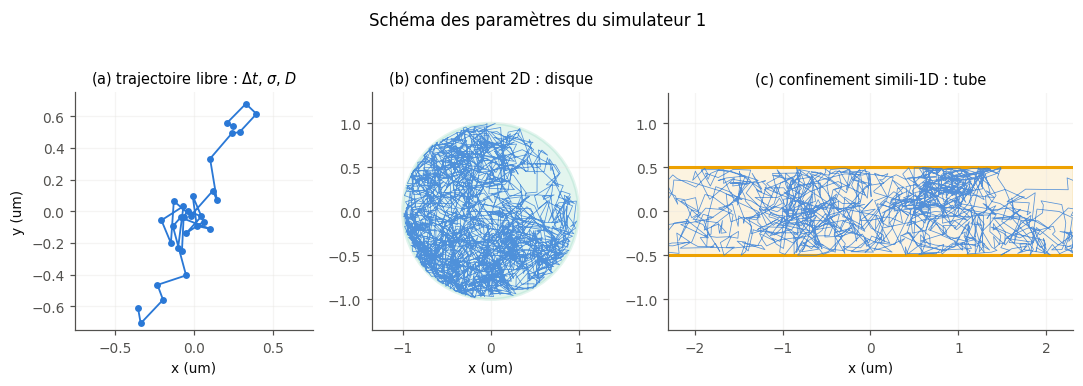

In [8]:
# --- paramètres du simulateur 1 -------------------------------
D1 = 1.0          # coefficient de diffusion, um^2/s
DT1 = 0.01        # intervalle entre détections, s (100 images/s)
T1 = 10.0         # durée totale, s
SIG1 = 0.03       # précision de localisation, um
R_DISQUE = 1.0    # rayon du disque de confinement, um (cercle de 2 um de diamètre)
D_TUBE = 1.0      # diamètre du tube de confinement, um

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2), width_ratios=[1, 1, 1.7])
BOITE = dict(fc="white", ec="none", alpha=.85, pad=1.5)


# (a) paramètres d'une trajectoire
t, R = simuler(Plan(1.), D1, 0.3, DT1, n=1, seed=10)
xy = R[:, 0] - R[:, 0].mean(0)

ax[0].plot(*xy.T, "-o", color=CAT[0], ms=3.5, lw=1.2)
ax[0].set_xlim(-.75, .75)
ax[0].set_ylim(-.75, .75)
ax[0].set_title("(a) trajectoire libre : $\\Delta t$, $\\sigma$, $D$")


# (b) confinement circulaire
t, Rd = simuler(Disque(R_DISQUE), D1, 20., DT1, n=1, seed=10)

ax[1].add_patch(Circle((0, 0), R_DISQUE, fc=CAT[2], alpha=.12, ec=CAT[2], lw=2))
ax[1].plot(*Rd[:, 0].T, color=CAT[0], lw=.5, alpha=.8)
ax[1].set_xlim(-1.35, 1.35)
ax[1].set_ylim(-1.35, 1.35)
ax[1].set_title("(b) confinement 2D : disque")


# (c) confinement en tube
t, Rt = simuler(Tube(D_TUBE), D1, 20., DT1, n=1, seed=10)

ax[2].axhspan(-D_TUBE/2, D_TUBE/2, color=CAT[3], alpha=.12)

for y in (-D_TUBE/2, D_TUBE/2):
    ax[2].axhline(y, color=CAT[3], lw=2)

ax[2].plot(*(Rt[:, 0] - [Rt[:, 0, 0].mean(), 0]).T, color=CAT[0], lw=.5, alpha=.8)
ax[2].set_xlim(-2.3, 2.3)
ax[2].set_ylim(-1.35, 1.35)
ax[2].set_title("(c) confinement simili-1D : tube")


for a_ in ax:
    a_.set_aspect("equal")
    a_.set_xlabel("x (um)")
    a_.grid(alpha=.4)

ax[0].set_ylabel("y (um)")

fig.suptitle("Schéma des paramètres du simulateur 1", y=1.04)
plt.show()

### A) MSD d'une trajectoire et estimation de $D$

L'analyse du déplacement carré moyen (MSD) permet d'extraire quantitativement le coefficient de diffusion $D$ d'une particule en mouvement brownien libre. En deux dimensions (2D), la relation théorique reliant la MSD au décalage temporel $\tau$ s'écrit $\text{MSD}(\tau) = 4D\tau$. Le coefficient de diffusion s'obtient donc directement à partir de la pente $b$ de la régression linéaire effectuée aux courts délais temporels, à partir de la formule $D = b/4$.

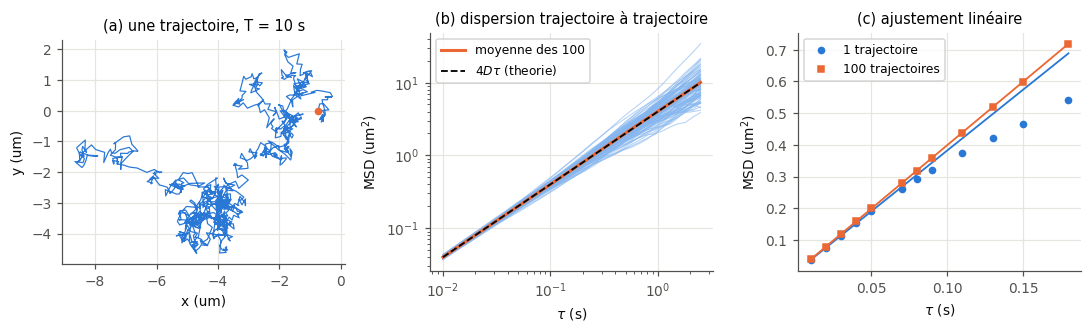

D vrai               : 1.000 um2/s
D, 1 trajectoire     : 0.956 um2/s
D, 100 trajectoires  : 0.998 um2/s


In [9]:
# --- paramètres du simulateur 1 -------------------------------
D1 = 1.0          # coefficient de diffusion, um^2/s
DT1 = 0.01        # intervalle entre détections, s (100 images/s)
T1 = 10.0         # durée totale, s
SIG1 = 0.03       # précision de localisation, um
R_DISQUE = 1.0    # rayon du disque de confinement, um (cercle de 2 um de diamètre)
D_TUBE = 1.0      # diamètre du tube de confinement, um
N = 100           # nombre de trajectoires à simuler

t, R = simuler(Plan(2.), D1, T1, DT1, n=N, seed=11)    # 20 trajectoires indépendantes
tau_1, m_1 = msd(R[:, :1], DT1)                        # MSD d'une seule trajectoire
tau_e, m_e = msd(R, DT1)                               # MSD moyennée sur les 20
D_1, _ = ajuste_msd(tau_1, m_1)
D_e, _ = ajuste_msd(tau_e, m_e)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))
ax[0].plot(*R[:, 0].T, color=CAT[0], lw=.8)
ax[0].plot(*R[0, 0], "o", color=CAT[1], label="depart")
ax[0].set_aspect("equal")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].set_title("(a) une trajectoire, T = %g s" % T1)

for k in range(N):
    tk, mk = msd(R[:, k:k+1], DT1)
    ax[1].plot(tk, mk, color=SEQ[0], lw=.7, alpha=.6)

ax[1].plot(tau_e, m_e, color=CAT[1], label=f"moyenne des {N}")
ax[1].plot(tau_e, 4*D1*tau_e, "--", color="k", lw=1.2, label="$4D\\tau$ (theorie)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].legend()
ax[1].set_title("(b) dispersion trajectoire à trajectoire")

ax[2].plot(tau_1[:12], m_1[:12], "o", color=CAT[0], label="1 trajectoire")
ax[2].plot(tau_1[:12], 4*D_1*tau_1[:12], color=CAT[0], lw=1.2)
ax[2].plot(tau_e[:12], m_e[:12], "s", color=CAT[1], label=f"{N} trajectoires")
ax[2].plot(tau_e[:12], 4*D_e*tau_e[:12], color=CAT[1], lw=1.2)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("MSD (um$^2$)")
ax[2].legend()
ax[2].set_title("(c) ajustement linéaire")

plt.show()

print("D vrai               : %.3f um2/s" % D1)
print("D, 1 trajectoire     : %.3f um2/s" % D_1)
print(f"D, {N} trajectoires  : %.3f um2/s" % D_e)


Les simulations effectuées permettent de retrouver la valeur de référence, $\tilde{D} = 1,000\text{ }\mu\text{m}^2/\text{s}$, validant ainsi le modèle théorique. En effet, une valeur de $D_{\text{1 traj}} = 0,956\text{ }\mu\text{m}^2/\text{s}$ a été déterminée à partir de la trajectoire seule correspondant à une erreur relative de $4,4\text{ }\%$. La valeur moyennée sur 100 trajectoires est de $D_{\text{100 traj}} = 0,998\text{ }\mu\text{m}^2/\text{s}$ pour une erreur relative de $0,2\text{ }\%$.

La valeur mesurée sur une seule trajectoire démontre qu'une trajectoire individuelle suffit pour obtenir une estimation exacte du coefficient de diffusion. La régression linéaire est volontairement restreinte aux premiers points de la courbe de MSD ($\tau$ court). En effet, pour des délais temporels longs ($\tau$ grand), le nombre de paires de points disponibles pour calculer la moyenne ($N_p - n$) diminue fortement, ce qui entraîne de très fortes fluctuations statistiques et fait diverger la MSD d'une trajectoire individuelle. Limiter le domaine d'ajustement aux premiers délais est donc indispensable pour conserver un résultat exact et stable.

Finalement, il est possible d'observer une diminution de l'erreur avec l'augmentation du nombre de trajectoires moyennées.



### B) Impact de la durée de la simulation

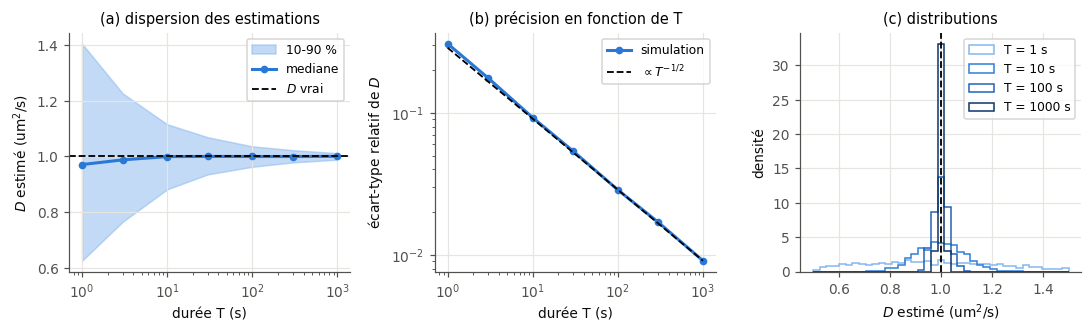

T =    1.0 s : D = 1.000 +- 0.308 um2/s  (31 %)
T =    3.0 s : D = 0.996 +- 0.175 um2/s  (18 %)
T =   10.0 s : D = 1.000 +- 0.093 um2/s  (9 %)
T =   30.0 s : D = 1.001 +- 0.054 um2/s  (5 %)
T =  100.0 s : D = 1.001 +- 0.029 um2/s  (3 %)
T =  300.0 s : D = 1.000 +- 0.017 um2/s  (2 %)
T = 1000.0 s : D = 1.000 +- 0.009 um2/s  (1 %)


In [10]:
def D_par_trajectoire(R, dt, nlag=10):
    """
    D estimé individuellement pour chaque trajectoire (nlag premiers décalages).
    """

    lags = np.arange(1, nlag + 1)
    m = np.array([((R[l:] - R[:-l])**2).sum(-1).mean(0) for l in lags])
    
    return np.polyfit(lags*dt, m, 1)[0]/4

t, R = simuler(Plan(2.), D1, 1000., DT1, n=1000, seed=12)
durees = np.array([1, 3, 10, 30, 100, 300, 1000])
est = [D_par_trajectoire(R[:int(T/DT1) + 1], DT1) for T in durees]
med = np.array([np.median(e) for e in est])
p10 = np.array([np.percentile(e, 10) for e in est])
p90 = np.array([np.percentile(e, 90) for e in est])
cv = np.array([e.std()/e.mean() for e in est])

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

ax[0].fill_between(durees, p10, p90, color=SEQ[0], alpha=.5, label="10-90 %")
ax[0].plot(durees, med, "o-", color=CAT[0], label="mediane")
ax[0].axhline(D1, ls="--", color="k", lw=1.2, label="$D$ vrai")
ax[0].set_xscale("log")
ax[0].set_xlabel("durée T (s)")
ax[0].set_ylabel("$D$ estimé (um$^2$/s)")
ax[0].legend()
ax[0].set_title("(a) dispersion des estimations")

ax[1].plot(durees, cv, "o-", color=CAT[0], label="simulation")
ax[1].plot(durees, cv[-1]*np.sqrt(durees[-1]/durees), "--", color="k", lw=1.2, label="$\\propto T^{-1/2}$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("durée T (s)")
ax[1].set_ylabel("écart-type relatif de $D$")
ax[1].legend()
ax[1].set_title("(b) précision en fonction de T")

for c, T in zip(seq(4), [1, 10, 100, 1000]):
    ax[2].hist(est[list(durees).index(T)], bins=np.linspace(0.5, 1.5, 40), histtype="step", color=c, lw=1.8, label="T = %g s" % T, density=True)

ax[2].axvline(D1, ls="--", color="k", lw=1.2)
ax[2].set_xlabel("$D$ estimé (um$^2$/s)")
ax[2].set_ylabel("densité")
ax[2].legend()
ax[2].set_title("(c) distributions")

plt.show()

for T, e in zip(durees, est):
    print("T = %6.1f s : D = %.3f +- %.3f um2/s  (%.0f %%)" % (T, e.mean(), e.std(), 100*e.std()/e.mean()))


La valeur moyenne du coefficient de diffusion estimé reste égale à la valeur attendue de $\langle D \rangle = 1{,}000 \pm 0,001\text{ }\mu\text{m}^2/\text{s}$, et ce, pour l'ensemble des durées $T$ simulées (de $1.0\text{ s}$ à $1000.0\text{ s}$). La durée d'acquisition n'introduit donc aucun biais systématique sur la mesure de $D$.

Il est cependant possible d'observer que l'incertitude relative diminue fortement avec l'augmentation de la durée $T$. La précision statistique suit une loi en $T^{-1/2}$. En effet, augmenter la durée d'un facteur 100 multiplie le nombre de pas de temps enregistrés par 100, ce qui réduit la dispersion relative d'un facteur $\sqrt{100} = 10$ (passant ainsi de $31\ \% \to 3\ \%$).

Pour des trajectoires très courtes, l'incertitude dépasse $25\text{ à }30\ \%$. Sur une trajectoire unique isolée de $1\text{ s}$, la valeur mesurée de $D$ peut facilement être surestimée ou sous-estimée d'un facteur 2 en raison des fluctuations stochastiques du mouvement brownien.

En pratique, les fluorophores blanchissent vite et les trajectoires expérimentales sont souvent courtes ($N$ petit). Pour compenser la forte dispersion d'une trajectoire courte individuelle, il est donc nécessaire de moyenner les courbes de MSD sur un ensemble de $N$ trajectoires.

<!--
$T = 1.0\text{ s}$ : $D = 1.000 \pm 0.308\text{ }\mu\text{m}^2/\text{s} \quad (\mathbf{31\ \%})$\
$T = 10.0\text{ s}$ : $D = 1.000 \pm 0.093\text{ }\mu\text{m}^2/\text{s} \quad (\mathbf{9\ \%})$\
$T = 100.0\text{ s}$ : $D = 1.001 \pm 0.029\text{ }\mu\text{m}^2/\text{s} \quad (\mathbf{3\ \%})$\
$T = 1000.0\text{ s}$ : $D = 1.000 \pm 0.009\text{ }\mu\text{m}^2/\text{s} \quad (\mathbf{1\ \%})$
-->

### C) Impact de la précision de localisation

L'incertitude de localisation spatiale de la caméra ($\sigma$) introduit un bruit blanc gaussien décorrélé d'une image à l'autre. En 2D, cette erreur modifie la courbe théorique du déplacement carré moyen en ajoutant une ordonnée à l'origine positive : 
$$\text{MSD}(\tau) = 4D\tau + 4\sigma^2.$$

On vérifie en même temps la règle du nombre optimal de points $p_{\min} = E(2 + 2,7\sqrt{x})$ en comparant, sur des trajectoires uniques, un ajustement à deux points à un ajustement à $p_{\min}$ points.

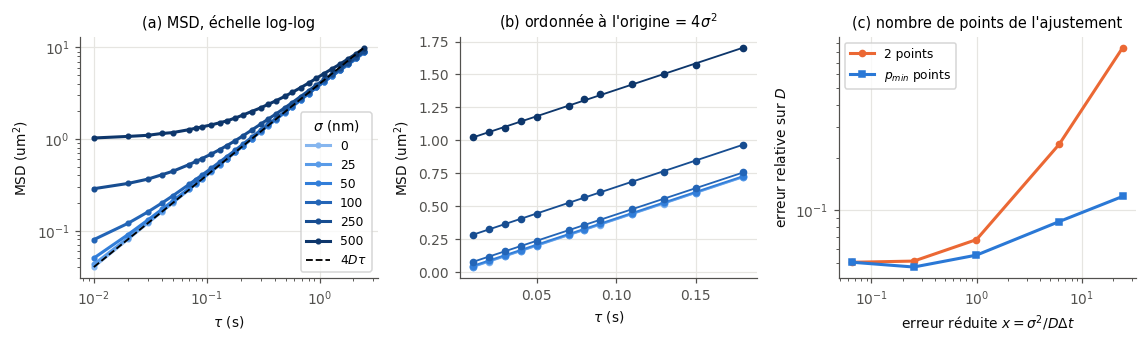

 sigma vrai   D estimé    sigma estimé      x     p_min   err(2 pts)  err(p_min)
      0 nm   1.001 um2/s       6 nm      0.004     2          5 %         5 %
     25 nm   1.001 um2/s      26 nm      0.066     2          5 %         5 %
     50 nm   1.000 um2/s      50 nm      0.253     3          5 %         5 %
    100 nm   0.997 um2/s     100 nm      0.997     4          7 %         6 %
    250 nm   1.005 um2/s     248 nm      6.103     8         24 %         9 %
    500 nm   1.001 um2/s     496 nm     24.542    15         85 %        12 %


In [11]:
sigmas = [0., 0.025, 0.05, 0.1, 0.25, 0.5]
t, R = simuler(Plan(2.), D1, 10.0, DT1, n=20, seed=13)

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
res = []

for c, s in zip(seq(len(sigmas)), sigmas):
    if s:
        Rb_ = bruit_localisation(R, s)
    else:
        Rb_ = R

    tau, m = msd(Rb_, DT1)
    Df, sf = ajuste_msd(tau, m)
    x = sf**2/(Df*DT1)
    p = min(int(2 + 2.7*np.sqrt(x)), len(tau))

    tau_p, mp = msd(Rb_, DT1, par_particule=True)
    D2 = np.array([ajuste_msd(tau_p, mp[:, k], npts=2)[0] for k in range(R.shape[1])])
    Dp = np.array([ajuste_msd(tau_p, mp[:, k], npts=p)[0] for k in range(R.shape[1])])
    res.append((s, Df, sf, x, p, D2.std()/abs(D2.mean()), Dp.std()/abs(Dp.mean())))

    ax[0].plot(tau, m, "o-", color=c, ms=3, label="%.0f" % (1000*s))
    ax[1].plot(tau[:12], m[:12], "o", color=c, ms=4)
    ax[1].plot(tau[:12], 4*Df*tau[:12] + 4*sf**2, color=c, lw=1.2)

ax[0].plot(tau, 4*D1*tau, "--", color="k", lw=1.2, label="$4D\\tau$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("MSD (um$^2$)")
ax[0].legend(title="$\\sigma$ (nm)")
ax[0].set_title("(a) MSD, échelle log-log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].set_title("(b) ordonnée à l'origine = $4\\sigma^2$")

xs = [r[3] for r in res[1:]]

ax[2].plot(xs, [r[5] for r in res[1:]], "o-", color=CAT[1], label="2 points")
ax[2].plot(xs, [r[6] for r in res[1:]], "s-", color=CAT[0], label="$p_{min}$ points")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("erreur réduite $x = \\sigma^2/D\\Delta t$")
ax[2].set_ylabel("erreur relative sur $D$")
ax[2].legend()
ax[2].set_title("(c) nombre de points de l'ajustement")

plt.show()

print(" sigma vrai   D estimé    sigma estimé      x     p_min   err(2 pts)  err(p_min)")

for s, Df, sf, x, p, e2, ep in res:
    print("  %5.0f nm   %.3f um2/s   %5.0f nm   %8.3f   %3d    %7.0f %%   %7.0f %%" % (1000*s, Df, 1000*sf, x, p, 100*e2, 100*ep))


L'ajustement linéaire avec une ordonnée à l'origine libre ($a = 4\sigma^2$) permet de retrouver la valeur réelle de l'erreur de localisation avec une bonne précision. L'erreur ralative maximale est atteinte pour la valeur de $\sigma_{\text{vrai}} = 0\text{ nm}$ dont l'estimation est de $\sigma_{\text{estimé}} = 6\text{ nm}$, représentant une valeur de 4%. Autrement, l'erreur relative demeure inférieure à $0,8\%$. La méthode permet toujours de déterminer le coefficient de diffusion $D$ avec exactitude et précision quel que soit le niveau de bruit, à condition de laisser l'ordonnée à l'origine libre lors de l'ajustement.

L'erreur de localisation réduite $x = \frac{\sigma^2}{D \Delta t}$ est un autre paramètre intéressant à analyser. Il s'agit d'un paramètre adimensionnel mesurant le rapport entre la variance du bruit de mesure et le déplacement propre de la particule pendant un intervalle $\Delta t$. Pour une incertitude de localisation spatiale importante ($\sigma = 250\text{ nm}$ et $500\text{ nm}$), on observe que $x \gg 1$ ($x = 6,103$ et $x = 24,542$). Il est possible d'en en conclure que le bruit de localisation masque presque totalement le déplacement réel de la particule aux courts délais temporels. Autrement dit, pour $\sigma \le 100\text{ nm}$ ($x \le 1$), le mouvement brownien réel surpasse ou équivaut au bruit de localisation. 

L'écart entre un ajustement sur les 2 premiers points seulement et l'ajustement optimal sur $p_{\text{min}} = E(2 + 2,7\sqrt{x})$ points démontre l'importance de cette règle. À faible bruit ($\sigma \le 50\text{ nm}, x < 0,3$), nous obtenons $p_{\text{min}} = 2 \text{ à } 3$ points et les deux méthodes donnent une erreur relative minimale et identique de 5 %. À fort bruit ($\sigma = 250\text{ nm}, x \approx 6,1$), un ajustement limité aux 2 premiers points engendre une erreur relative de 24 %, alors que la règle $p_{\text{min}} = 8$ points maintient l'erreur à seulement 9 %. Enfin, à très fort bruit ($\sigma = 500\text{ nm}, x \approx 24,5$), l'ajustement sur 2 points engendre une erreur relative de 85 %, tandis que l'ajustement adaptatif sur $p_{\text{min}} = 15$ points permet de la restreindre à 12 %.

Lorsque le bruit de localisation est important ($x \gg 1$), les tout premiers points de la courbe MSD sont dominés par le bruit de mesure. Il est alors nécessaire d'inclure davantage de points ($p_{\text{min}}$) dans la régression linéaire afin de moyenner efficacement l'incertitude de localisation, sans pour autant aller trop loin dans la courbe pour éviter les fluctuations de fin de trajectoire.

### D) Confinement

La géométrie du confinement est définie par un cercle de 2 µm de diamètre ($R=1$ µm) et un tube de 1 µm de diamètre. Pour une particule confinée, le déplacement quadratique moyen (MSD) atteint un plateau à long temps donné par $\mathrm{MSD}(\infty)=2(\mathrm{Var},x+\mathrm{Var},y)$. Dans le cas d’un disque uniforme, on a $\mathrm{Var},x=\mathrm{Var},y=R^2/4$, ce qui donne un plateau égal à $R^2$. Pour un segment de largeur $d$, la variance vaut $\mathrm{Var}=d^2/12$, donnant un plateau unidimensionnel de $d^2/6$.

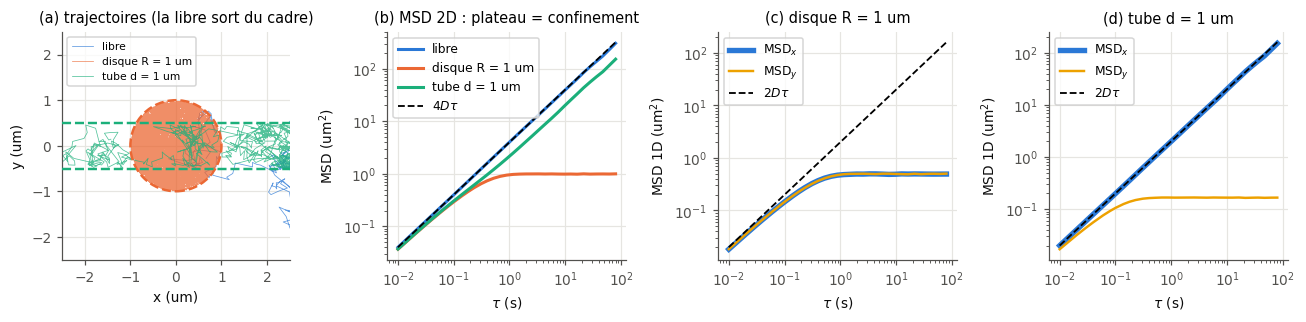

disque : plateau 2D = 0.993 um2  ->  R = 1.00 um (vrai 1.00)
tube   : plateau y  = 0.166 um2  ->  d = 1.00 um (vrai 1.00)
tube   : MSD_x linéaire, D_x = 0.995 um2/s (vrai 1.00)


In [12]:
T_LONG = 200.

geoms = [("libre", Plan(2.), CAT[0]),
         ("disque R = 1 um", Disque(R_DISQUE), CAT[1]),
         ("tube d = 1 um", Tube(D_TUBE), CAT[2])]

fig, ax = plt.subplots(1, 4, figsize=(12, 3.0))
traj = {}

for k, (nom, dom, c) in enumerate(geoms):
    t, R = simuler(dom, D1, T_LONG, DT1, n=30, seed=14)
    traj[nom] = R
    ax[0].plot(*R[:5000, 0].T, color=c, lw=.5, alpha=.75, label=nom)   # 50 s, cadre +-2.5 um
    tau, m = msd(R, DT1, frac=0.4)
    ax[1].plot(tau, m, color=c, lw=2, label=nom)

ax[0].add_patch(Circle((0, 0), R_DISQUE, fill=False, ec=CAT[1], lw=1.6, ls="--", zorder=5))

for y in (-D_TUBE/2, D_TUBE/2):
    ax[0].axhline(y, color=CAT[2], lw=1.6, ls="--", zorder=5)

ax[0].set_xlim(-2.5, 2.5)
ax[0].set_ylim(-2.5, 2.5)
ax[0].set_aspect("equal")
ax[0].set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
ax[0].legend(loc="upper left", fontsize=7)
ax[0].set_title("(a) trajectoires (la libre sort du cadre)")

ax[1].plot(tau, 4*D1*tau, "--", color="k", lw=1.2, label="$4D\\tau$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("MSD (um$^2$)")
ax[1].legend()
ax[1].set_title("(b) MSD 2D : plateau = confinement")

# decouplage des deux axes
for k, (nom, ax_k) in enumerate([("disque R = 1 um", ax[2]), ("tube d = 1 um", ax[3])]):
    for axe, lab, c, w in [(0, "x", CAT[0], 3.5), (1, "y", CAT[3], 1.6)]:
        tau, m = msd(traj[nom], DT1, frac=0.4, axe=axe)
        ax_k.plot(tau, m, color=c, lw=w, label="MSD$_%s$" % lab)

    ax_k.plot(tau, 2*D1*tau, "--", color="k", lw=1.2, label="$2D\\tau$")
    ax_k.set_xscale("log")
    ax_k.set_yscale("log")
    ax_k.set_xlabel("$\\tau$ (s)")
    ax_k.set_ylabel("MSD 1D (um$^2$)")
    ax_k.legend()
    ax_k.set_title("(%s) %s" % ("cd"[k], nom))

plt.show()

tau, m = msd(traj["disque R = 1 um"], DT1, frac=0.4)
print("disque : plateau 2D = %.3f um2  ->  R = %.2f um (vrai %.2f)" % (plateau(tau, m), np.sqrt(plateau(tau, m)), R_DISQUE))

tau, my = msd(traj["tube d = 1 um"], DT1, frac=0.4, axe=1)
print("tube   : plateau y  = %.3f um2  ->  d = %.2f um (vrai %.2f)" % (plateau(tau, my), np.sqrt(6*plateau(tau, my)), D_TUBE))

tau, mx = msd(traj["tube d = 1 um"], DT1, frac=0.4, axe=0)
print("tube   : MSD_x linéaire, D_x = %.3f um2/s (vrai %.2f)" % (ajuste_msd(tau, mx, ndim=1)[0], D1))

Lorsqu'une particule est confinée par des parois réfléchissantes, celle-ci n'a pas le temps de diffuser suffisament pour frapper les parois pour de courts délais temporels ($\tau$ petit). Ainsi, la courbe de MSD reste linéaire et suit la pente brownienne typique ($\text{MSD}(\tau) \approx 4D\tau$). Inversement, pour de longs délais temporels ($\tau \to \infty$), le déplacement maximal que peut atteindre la particule est limité par les dimensions du domaine. La MSD cesse d'augmenter pour atteindre une valeur constante égale à $\text{MSD}(\infty) = 2(\text{Var}(x) + \text{Var}(y))$.

Pour un disque de rayon $R$, la position de la particule est distribuée uniformément sur la surface. La variance spatiale selon chaque axe vaut $\text{Var}(x) = \text{Var}(y) = R^2/4$. La théorie prédit ainsi, pour le plateau 2D à temps long :
$$\text{MSD}_{2D}(\infty) = 2 \left(\frac{R^2}{4} + \frac{R^2}{4}\right) = R^2.$$

Le résultat de la simulation donne un plateau de $\text{Plateau}_{2D} = 0,993\text{ }\mu\text{m}^2$, ce qui permet d'extraire un rayon de $R = 1,00\text{ }\mu\text{m}$, parfaitement conforme à la valeur réelle de $1,00\text{ }\mu\text{m}$. La trajectoire de la particule confinée permet donc de retrouver la géométrie du disque avec exactitude.

Dans le cas d'une particule confinée dans un tube orienté selon l'axe $x$ et de largeur $d$ selon l'axe $y$, la position sur l'axe confiné ($y$) est bornée sur un intervalle de largeur $d$. La variance spatiale vaut $\text{Var}(y) = d^2/12$. La théorie prédit ainsi un plateau 1D égal à : 
$$\text{MSD}_{y}(\infty) = 2 \cdot \text{Var}(y) = \frac{d^2}{6}.$$

La simulation donne un plateau de $\text{Plateau}_y = 0,166\text{ }\mu\text{m}^2$, correspondant à un diamètre extrait de $d = 1,00\text{ }\mu\text{m}$, exactement égal à la valeur réelle de $1,00\text{ }\mu\text{m}$. Inversement, sur l'axe libre ($x$), le mouvement n'est pas limité. La MSD selon $x$ conserve donc la croissance linéaire brownienne attendue :
$$\text{MSD}_x(\tau) = 2 D_x \tau.$$

La mesure de la pente donne $D_x = 0,995\text{ }\mu\text{m}^2/\text{s}$, extrêmement proche de la valeur vraie de $1,00\text{ }\mu\text{m}^2/\text{s}$.

Il est ainsi possible de découpler les mouvements en fonction des deux dimensions pour faire ressortir les confinements. Ce découplage est même une nécessité. En effet, si l'on calcule uniquement la MSD 2D globale du tube, la croissance linéaire selon $x$ masque le plateau selon $y$. La courbe totale reste linéaire avec une pente plus faible, ce qui pourrait amener à conclure à tort que la particule diffusse librement avec un coeffeicient de diffusion plus faible.

### E) Film vu par une caméra

La trajectoire est convoluée par une PSF gaussienne, échantillonnée par les pixels, puis un fond et
un bruit de Poisson sont ajoutés.

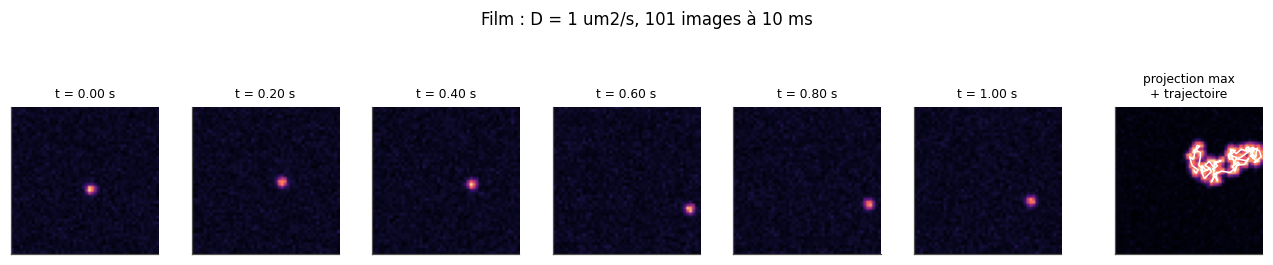

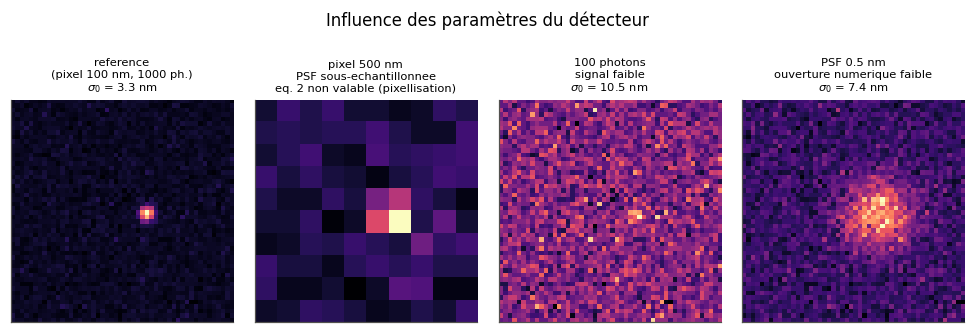

PSF                 : sigma = 105 nm  (FWHM = 247 nm), lambda = 0.5 um, NA = 1.0
Pixel               : 100 nm  -> 1.0 pixels par sigma de PSF (critère de Nyquist)
Photons / molécule  : 1000 par image ; fond : 10 photons/pixel
Localisation        : sigma_0 = s0/sqrt(N) = 3.3 nm  (statique, Michalet eq. 2)
                      sigma   = 4.6 nm  (pose t_E = 10 ms, eq. 4)
Déplacement / image : sqrt(4 D dt) = 200 nm
Erreur réduite      : x = sigma^2/(D dt) = 1.1e-03  ->  p_min = 2 points de MSD


In [13]:
# --- paramètres du détecteur ------------------------------------------------
LAMBDA = 0.500          # longueur d'onde d'emission, um
NA = 1.0                # ouverture numérique
PSF = 0.21*LAMBDA/NA    # écart-type de la PSF ~ 0.21 lambda/NA
CHAMP = 5               # largeur du champ, um
PIXEL = 0.1             # largeur d'un pixel, um
PHOTONS = 1000          # nombre de photons détectés

cam = Camera(pixel=PIXEL, psf=PSF, champ=CHAMP, photons=PHOTONS, fond=10)

t, R = simuler(Plan(1.), D1, 1.0, DT1, n=1, seed=15)
film = cam.film(R, seed=15)

fig, ax = plt.subplots(1, 7, figsize=(12, 2.1), width_ratios=[1]*6 + [1.25])

for a_, i in zip(ax, np.linspace(0, len(film) - 1, 6).astype(int)):
    a_.imshow(film[i], vmin=0, vmax=film.max())
    a_.set_title("t = %.2f s" % t[i], fontsize=8)

ax[6].imshow(film.max(0), extent=[-cam.champ/2, cam.champ/2]*2, origin="lower")
ax[6].plot(*R[:, 0].T, color="w", lw=1)
ax[6].set_title("projection max\n+ trajectoire", fontsize=8)

for a_ in ax:
    a_.set_xticks([])
    a_.set_yticks([])
    a_.grid(False)

fig.suptitle("Film : D = %g um2/s, %d images à %g ms" % (D1, len(film), 1e3*DT1), y=1.12)

plt.show()

# influence de chaque paramètre du détecteur, sur la même position
variantes = [(f"reference\n(pixel {PIXEL*1000:.0f} nm, {PHOTONS} ph.)", cam, True),
             (f"pixel {PIXEL*5*1000:.0f} nm\nPSF sous-echantillonnee",
              Camera(pixel=PIXEL*5, psf=PSF, champ=CHAMP, photons=PHOTONS//10, fond=10), False),
             (f"{PHOTONS//10} photons\nsignal faible",
              Camera(pixel=PIXEL, psf=PSF, champ=CHAMP, photons=PHOTONS//10, fond=10), True),
             (f"PSF {PSF*5:.1f} nm\nouverture numerique faible",
              Camera(pixel=PIXEL, psf=PSF*5, champ=CHAMP, photons=PHOTONS*5, fond=10), True)]

fig, ax = plt.subplots(1, 4, figsize=(9, 2.7))

for a_, (titre, c, valide) in zip(ax, variantes):
    a_.imshow(c.image(R[20], np.random.default_rng(1)))

    if valide:
        sous_titre = "$\\sigma_0$ = %.1f nm" % (1000*c.precision())
    else:
        sous_titre = "eq. 2 non valable (pixellisation)"

    a_.set_title("%s\n%s" % (titre, sous_titre), fontsize=7.5)
    a_.set_xticks([])
    a_.set_yticks([])
    a_.grid(False)

fig.suptitle("Influence des paramètres du détecteur", y=1.10)

plt.show()

print("PSF                 : sigma = %.0f nm  (FWHM = %.0f nm), lambda = %g um, NA = %.1f" % (1000*PSF, 1000*2.355*PSF, LAMBDA, NA))
print("Pixel               : %.0f nm  -> %.1f pixels par sigma de PSF (critère de Nyquist)" % (1000*cam.pixel, PSF/cam.pixel))
print("Photons / molécule  : %d par image ; fond : %d photons/pixel" % (cam.photons, cam.fond))
print("Localisation        : sigma_0 = s0/sqrt(N) = %.1f nm  (statique, Michalet eq. 2)" % (1000*cam.precision()))
print("                      sigma   = %.1f nm  (pose t_E = %g ms, eq. 4)" % (1000*cam.precision_dynamique(D1, DT1), 1e3*DT1))
print("Déplacement / image : sqrt(4 D dt) = %.0f nm" % (1000*np.sqrt(4*D1*DT1)))
print("Erreur réduite      : x = sigma^2/(D dt) = %.1e  ->  p_min = %d points de MSD" % (cam.precision()**2/(D1*DT1), int(2 + 2.7*np.sqrt(cam.precision()**2/(D1*DT1)))))

Pour une longueur d'onde d'émission $\lambda = 0,500\text{ }\mu\text{m}$ et une ouverture numérique $\text{NA} = 1,0$, l'écart-type de la PSF gaussienne vaut $s_0 \approx 0,21 \, \lambda / \text{NA} = 105\text{ nm}$ (soit une largeur à mi-hauteur $\text{FWHM} = 2,355 \, s_0 = 247\text{ nm}$). La PSF fixe la résolution optique ultime du microscope.

Le pixel de la taille de $100\text{ nm}$ permet un échantillonnage de 1,0 pixel par $\sigma$ de PSF, correspondant à 2,47 pixels par FWHM. Ce choix respecte le critère d'échantillonnage spatial de Nyquist-Shannon qui impose au moins 2 pixels par FWHM. Il évite le sous-échantillonnage ainsi que le sur-échantillonnage excessif qui étalerait les photons sur trop de pixels, dégradant le rapport signal sur bruit.

Chaque molécule émet en moyenne $N_{\text{ph}} = 1000\text{ photons}$ par image, distribués selon le profil de la PSF. La détection de la lumière, qu'il s'agisse du signal fluorescent ou du fond continu de 10 photons/pixel, suit une statistique de Poisson.


Pour une particule immobile, l'incertitude théorique de position selon l'équation (2) de Michalet s'écrit : 
$$\sigma_0 = \frac{s_0}{\sqrt{N_{\text{ph}}}} = \frac{105\text{ nm}}{\sqrt{1000}} = 3,3\text{ nm}$$

Comparée au déplacement physique moyen de la particule par image ($\sqrt{4D \Delta t} = \sqrt{4 \times 1,0 \times 0,01} = 200\text{ nm}$), la position statique est largement sur-résolue (l'erreur ne représente que $\sim 1,6\ \%$ du déplacement).

Pendant le temps d'exposition $t_E = \Delta t = 10\text{ ms}$, la particule diffuse, ce qui élargit la tache de fluorescence apparente. Selon l'équation (4) de Michalet, l'incertitude dynamique corrigée pour le mouvement est : $$\sigma = \sigma_0 \sqrt{1 + \frac{D t_E}{s_0^2}} = 3,3 \times \sqrt{1 + \frac{1{,}0 \times 0{,}01}{0{,}105^2}} = 4,6\text{ nm}$$ 

Le mouvement pendant la pose ajoute ainsi environ $39\ \%$ d'incertitude par rapport au cas statique.

En combinant le bruit de localisation et le déplacement brownien, l'erreur de localisation réduite vaut : 
$$x = \frac{\sigma^2}{D \Delta t} = \frac{(0,0033\text{ }\mu\text{m})^2}{1,0\text{ }\mu\text{m}^2/\text{s} \times 0,01\text{ s}} \approx 1,1 \times 10^{-3}$$

Comme $x = 1,1 \times 10^{-3} \ll 1$, nous sommes dans le régime de faible bruit de Michalet. La formule $p_{\text{min}} = E(2 + 2,7\sqrt{x})$ donne exactement $p_{\text{min}} = 2\text{ points}$.

Grâce à un flux photonique élevé (1000 photons/image) et un échantillonnage optique adapté, le bruit de localisation est négligeable devant le déplacement réel de la particule. Les deux premiers points de la courbe de MSD suffisent donc amplement pour extraire le coefficient de diffusion $D$ avec la précision maximale.

<a id="2"></a>
# 2. Simulateur 2 — FRAP

La simulation considère une population de particules indépendantes se déplaçant dans une boîte à parois réfléchissantes. Les paramètres utilisés sont la durée totale $T$, le pas temporel $\Delta t$, la densité de particules, le coefficient de diffusion $D$, la fraction immobile et le rayon de la zone blanchie $R_b$. 

En s'appuyant sur Kenworthy, Biophysical Journal 122, 3577 (2023), l'analyse d'une courbe de FRAP repose sur deux grandeurs distinctes, soit la cinétique de récupération, caractérisée par $t_{1/2}$, et la fraction mobile. Le choix du modèle doit notamment tenir compte de la géométrie et de la taille de la zone blanchie, des conditions aux limites et du nombre de dimensions du retour à l'équilibre.

L'analyse se limite donc à ces deux grandeurs, extraites par un ajustement mono-exponentiel. Le coefficient de diffusion $D$ est ici un paramètre d'entrée de la simulation et non une quantité mesurée à partir de la courbe. Enfin, les trois hypothèses de base considérées par Kenworthy, soit un blanchiment irréversible, des variations de fluorescence dues uniquement aux molécules marquées et un marquage non perturbant, sont satisfaites par construction dans la simulation.

## Film FRAP vu par la caméra

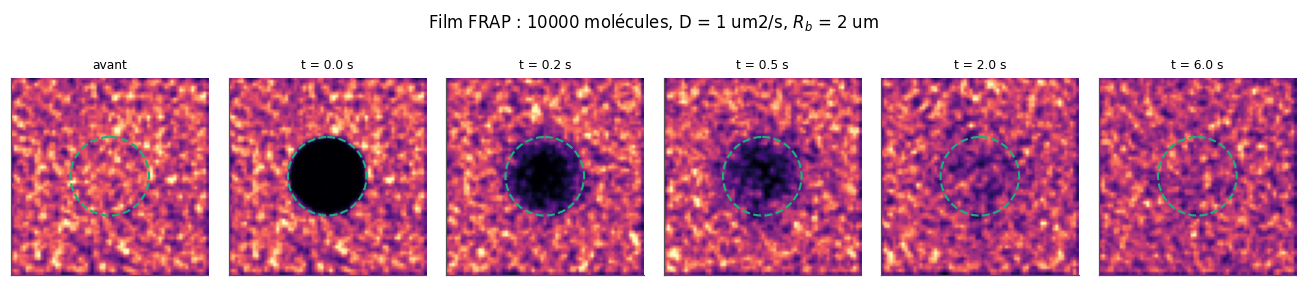

In [27]:
# --- paramètres de référence du simulateur 2 -------------------------------
L2 = 10.0                   # côté de la boîte, um (grande devant Rb pour un réservoir quasi infini)
RB = 2.0                    # rayon de la zone blanchie, um
DENS2 = 100.0                # densité, molécules / um^2
N2 = int(DENS2*L2**2)       # nombre de molécules
D2 = 1.0                    # coefficient de diffusion, um^2/s

t, R = simuler(Boite(L2), D2, 6.0, 0.05, n=N2, seed=20)
fluo = (R[0]**2).sum(-1) >= RB**2                 # molécules non blanchies
cam = Camera(pixel=0.15, psf=PSF, champ=10., photons=200, fond=5)

instants = [0, 0, 4, 10, 40, 120]
fig, ax = plt.subplots(1, 6, figsize=(12, 2.4))
rng = np.random.default_rng(3)
ech = cam.image(R[0], rng)                          # image avant blanchiment
vmax = np.percentile(ech, 99.5)

for k, (a, i) in enumerate(zip(ax, instants)):
    if k == 0:
        m = np.ones(N2, bool)          # 1re vignette : avant blanchiment
        titre = "avant"
    else:
        m = fluo
        titre = "t = %.1f s" % t[i]

    a.imshow(cam.image(R[i][m], rng), vmin=0, vmax=vmax)
    a.add_patch(Circle((cam.npix/2 - .5,)*2, RB/cam.pixel, fill=False, ec=CAT[2], lw=1.4, ls="--"))
    a.set_title(titre, fontsize=8)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

fig.suptitle("Film FRAP : %d molécules, D = %g um2/s, $R_b$ = %g um" % (N2, D2, RB), y=1.06)

plt.show()


### A) Impact du coefficient de diffusion

$\Delta t$ et $T$ sont mis à l'échelle du temps caractéristique $R_b^2/D$, ce qui garde le même nombre de points utiles quel que soit $D$.

La boîte fait 10 µm de côté pour un disque de rayon 2 µm, soit un rapport d'aire de 12,6 %. Dans une géométrie fermée de taille finie $L$, le photoblanchiment détruit de façon irréversible une fraction des fluorophores présents dans la tache circulaire de rayon $R_b$. La fluorescence totale du système diminue donc de manière définitive du ratio entre la surface de la tache et la surface totale du domaine : 
$$F_{\infty}^{\text{théorique}} = 1 - \frac{\pi R_b^2}{L^2} = 1 - \frac{\pi \times R_b^2}{L^2} = 0,874$$

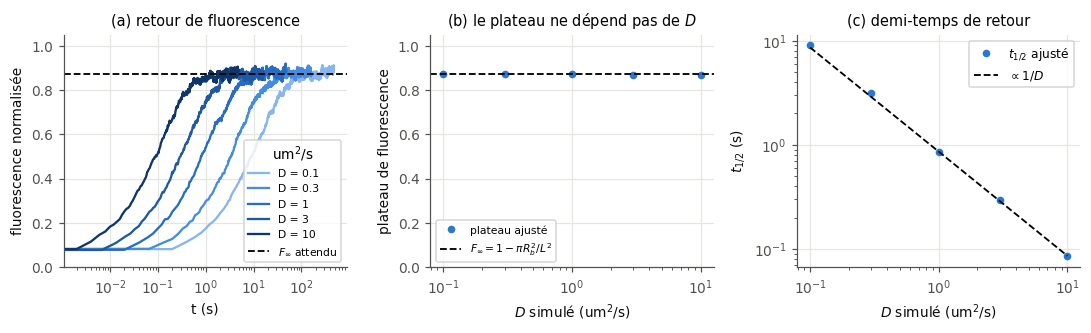

  plateau attendu en boîte fermée : F_inf = 1 - pi Rb^2/L^2 = 0.874

  D simulé    plateau    t_1/2 (s)    t_1/2 x D
     0.10      0.872       8.981        0.898
     0.30      0.871       3.146        0.944
     1.00      0.871       0.860        0.860
     3.00      0.868       0.292        0.877
    10.00      0.867       0.085        0.848


In [28]:
Ds = [0.1, 0.3, 1.0, 3.0, 10.0]
courbes = []
ajust = []

for k, D in enumerate(Ds):
    t, F = frap(Boite(L2), D, RB, 12*RB**2/D, 0.005*RB**2/D, N2, n_rep=4, seed=21 + 100*k)
    courbes.append((t, F))
    ajust.append(ajuste_frap(t, F))

F_INF = plateau_attendu(RB, L2)
fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

for c, D, (t, F) in zip(seq(len(Ds)), Ds, courbes):
    ax[0].plot(t, F, color=c, lw=1.5, label="D = %g" % D)

ax[0].axhline(F_INF, ls="--", color="k", lw=1.2, label="$F_\\infty$ attendu")
ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisée")
ax[0].set_ylim(0, 1.05)
ax[0].legend(title="um$^2$/s", fontsize=7)
ax[0].set_title("(a) retour de fluorescence")

ax[1].plot(Ds, [a["mobile"] for a in ajust], "o", color=CAT[0], label="plateau ajusté")
ax[1].axhline(F_INF, ls="--", color="k", lw=1.2, label="$F_\\infty = 1 - \\pi R_b^2/L^2$")
ax[1].set_xscale("log")
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("$D$ simulé (um$^2$/s)")
ax[1].set_ylabel("plateau de fluorescence")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) le plateau ne dépend pas de $D$")

t_demis = np.array([a["t_demi"] for a in ajust])
ref = t_demis[Ds.index(1.0)]/np.array(Ds)

ax[2].plot(Ds, t_demis, "o", color=CAT[0], label="$t_{1/2}$ ajusté")
ax[2].plot(Ds, ref, "--", color="k", lw=1.2, label="$\\propto 1/D$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$D$ simulé (um$^2$/s)")
ax[2].set_ylabel("$t_{1/2}$ (s)")
ax[2].legend()
ax[2].set_title("(c) demi-temps de retour")

plt.show()

print("  plateau attendu en boîte fermée : F_inf = 1 - pi Rb^2/L^2 = %.3f" % F_INF)
print()
print("  D simulé    plateau    t_1/2 (s)    t_1/2 x D")

for D, a in zip(Ds, ajust):
    print("  %7.2f    %7.3f    %8.3f    %9.3f" % (D, a["mobile"], a["t_demi"], a["t_demi"]*D))

Les résultats de la simulation valident la limite théorique. En effet, pour toutes les valeurs de $D$ (de $0,10$ à $10,00\text{ }\mu\text{m}^2/\text{s}$), le plateau réatteint varie entre $0,867$ et $0,872$, soit un écart relatif inférieur à $ 0,8\ \%$. Il est possible d'en conclure que l'amplitude du plateau final est indépendante du coefficient de diffusion $D$. En boîte fermée, les molécules blanchies restent dans le domaine et se mélangent uniformément aux molécules fluorescentes, fixant le plateau d'équilibre final uniquement à partir du rapport des surfaces.

À l'inverse du plateau, le demi-temps de recouvrement $t_{1/2}$, qui est le temps requis pour atteindre la moitié de la récupération maximale, dépend de manière inversement proportionnelle à $D$. En multipliant le demi-temps mesuré par le coefficient de diffusion correspondant, il est possible d'observer que le produit $t_{1/2} \times D$ reste constant, soit :
$$t_{1/2} \times D \approx 0,88 \pm 0,04\text{ }\mu\text{m}^2.$$

Pour une tache circulaire de rayon $R_b$, la solution analytique du recouvrement par diffusion pure donne :
$$t_{1/2} = \gamma \frac{R_b^2}{D} \Rightarrow t_{1/2} \times D = \gamma R_b^2$$
où $\gamma \approx 0,224$ est un facteur de forme lié au profil d'illumination. Le produit $t_{1/2} \times D$ ne dépend donc que du rayon du faisceau de blanchiment $R_b$ et non de la dynamique de la molécule.

### B) Impact de la population immobile

Seules les molécules libres participent au mélange et à la ré-équilibration de la fluorescence après le photoblanchiment. La valeur théorique du plateau s'obtient en pondérant le plateau en boîte fermée par la fraction mobile $f_{\text{mobile}} = 1 - f_{\text{immobile}}$ : 
$$F_{\infty}^{\text{attendu}} = (1 - f_{\text{immobile}}) \times \left(1 - \frac{\pi R_b^2}{L^2}\right) = (1 - f_{\text{immobile}}) \times 0,874.$$

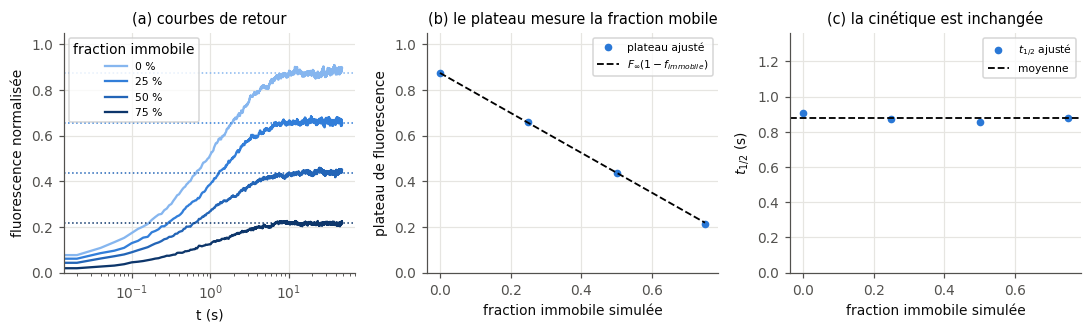

  f_immobile   plateau mesuré   plateau attendu   t_1/2 (s)
      0.00            0.874             0.874       0.908
      0.25            0.658             0.656       0.873
      0.50            0.436             0.437       0.856
      0.75            0.214             0.219       0.877


In [16]:
f_imm = [0., 0.25, 0.5, 0.75]
res_b = []

for k, fi in enumerate(f_imm):
    t, F = frap(Boite(L2), D2, RB, 12*RB**2/D2, 0.005*RB**2/D2, N2, f_immobile=fi, n_rep=6, seed=22 + 100*k)
    res_b.append((t, F, ajuste_frap(t, F)))

attendus = [plateau_attendu(RB, L2, fi) for fi in f_imm]
fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))

for c, fi, att, (t, F, a) in zip(seq(len(f_imm)), f_imm, attendus, res_b):
    ax[0].plot(t, F, color=c, lw=1.5, label="%.0f %%" % (100*fi))
    ax[0].axhline(att, color=c, ls=":", lw=1)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisée")
ax[0].set_ylim(0, 1.05)
ax[0].legend(title="fraction immobile", fontsize=7)
ax[0].set_title("(a) courbes de retour")

ax[1].plot(f_imm, [a["mobile"] for _, _, a in res_b], "o", color=CAT[0], label="plateau ajusté")
ax[1].plot(f_imm, attendus, "--", color="k", lw=1.2, label="$F_\\infty(1 - f_{immobile})$")
ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("fraction immobile simulée")
ax[1].set_ylabel("plateau de fluorescence")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) le plateau mesure la fraction mobile")

ax[2].plot(f_imm, [a["t_demi"] for _, _, a in res_b], "o", color=CAT[0], label="$t_{1/2}$ ajusté")
ax[2].axhline(np.mean([a["t_demi"] for _, _, a in res_b]), ls="--", color="k", lw=1.2, label="moyenne")
ax[2].set_ylim(0, 1.5*max(a["t_demi"] for _, _, a in res_b))
ax[2].set_xlabel("fraction immobile simulée")
ax[2].set_ylabel("$t_{1/2}$ (s)")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) la cinétique est inchangée")

plt.show()

print("  f_immobile   plateau mesuré   plateau attendu   t_1/2 (s)")

for fi, att, (_, _, a) in zip(f_imm, attendus, res_b):
    print("  %8.2f     %12.3f     %13.3f    %8.3f" % (fi, a["mobile"], att, a["t_demi"]))

Les résultats expérimentaux de la simulation concordent avec la théorie. En effet, l'amplitude du plateau diminue linéairement avec l'augmentation de la fraction de particules immobiles. Les molécules immobiles blanchies au centre de la tache ne sont jamais remplacées, ce qui abaisse le niveau maximal de fluorescence réatteint.

À l'inverse du plateau, le demi-temps de recouvrement demeure pratiquement constant, présentant une valeur de $t_{1/2} \approx 0,88 \pm 0,02\text{ s}$, pour toutes les conditions de simulation. Les molécules immobiles ne participent pas au flux de diffusion. La vitesse à laquelle le tache photoblanchie se comble dépend uniquement des propriétés de transport des molécules mobiles, définies par leur coefficient de diffusion $D$ et la taille du spot $R_b$. Ainsi, la présence de molécules immobiles réduit la hauteur maximale du recouvrement, mais ne ralentit et n'accélère pas la dynamique de diffusion des molécules libres.

### C) Impact de la géométrie : 2D libre contre tube de 1 µm

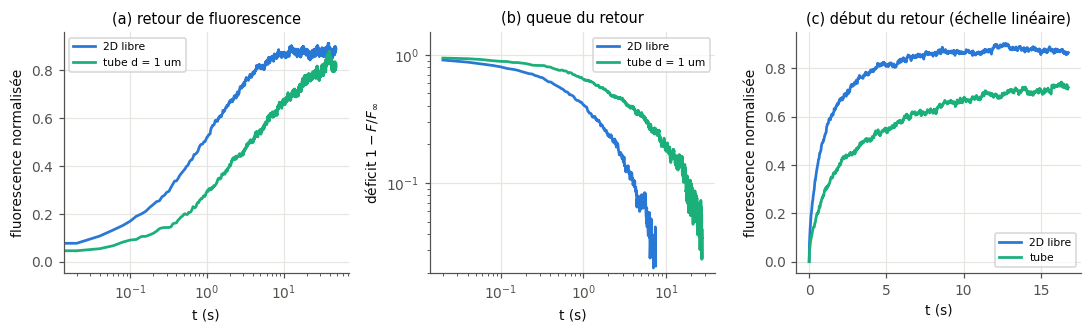

  géométrie        plateau   t_1/2 (s)   pente du déficit sur 1-5 s
  2D libre           0.873      0.903            -1.17
  tube d = 1 um      0.793      3.022            -0.42


In [ ]:
L_TUBE = 100.0
DENS_TUBE = 100.0
PLANCHER = 0.02        # sous ce deficit, F fluctue autour du plateau : c'est du bruit
FEN_PENTE = (1.0, 5.0)  # fenetre de temps ou l'on compare les pentes, en s

geo = [("2D libre", Boite(L2), N2, CAT[0]),
       ("tube d = 1 um", Tube(1.0, L_TUBE), int(DENS_TUBE*L_TUBE), CAT[2])]
res_c = []

for k, (nom, dom, n, c) in enumerate(geo):
    t, F = frap(dom, D2, RB, 12*RB**2, 0.005*RB**2, n, n_rep=4, seed=23 + 100*k)
    res_c.append((nom, t, F, c))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.1))
pentes = []

for nom, t, F, c in res_c:
    A = F[int(0.8*len(F)):].mean()
    deficit = 1 - F[1:]/A
    tt = t[1:]

    sous = np.flatnonzero(deficit < PLANCHER)

    if len(sous):
        fin = sous[0]
    else:
        fin = len(deficit)

    util = (tt >= FEN_PENTE[0]) & (tt <= FEN_PENTE[1]) & (deficit > PLANCHER)
    pentes.append(np.polyfit(np.log(tt[util]), np.log(deficit[util]), 1)[0])

    ax[0].plot(t, F, color=c, lw=1.8, label=nom)
    ax[1].plot(tt[:fin], deficit[:fin], color=c, lw=1.8, label=nom)

ax[0].set_xscale("log")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("fluorescence normalisée")
ax[0].legend(fontsize=7)
ax[0].set_title("(a) retour de fluorescence")

ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_ylim(PLANCHER, 1.5)
ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("déficit $1 - F/F_\\infty$")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) queue du retour")

i = int(0.35*len(res_c[0][1]))

ax[2].plot(res_c[0][1][:i], res_c[0][2][:i], color=CAT[0], lw=1.8, label="2D libre")
ax[2].plot(res_c[0][1][:i], res_c[1][2][:i], color=CAT[2], lw=1.8, label="tube")
ax[2].set_xlabel("t (s)")
ax[2].set_ylabel("fluorescence normalisée")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) début du retour (échelle linéaire)")

plt.show()

print("  géométrie        plateau   t_1/2 (s)   pente du déficit sur %g-%g s" % FEN_PENTE)

for (nom, t, F, c), p in zip(res_c, pentes):
    a = ajuste_frap(t, F)
    print("  %-14s   %7.3f   %8.3f   %14.2f" % (nom, a["mobile"], a["t_demi"], p))

Deux simulations ont été générées, soit une 2D sans contraintes et une autre en simili 1D (tube de 1 um de diamètre). Dans les deux cas, le coefficient de diffusion est identique, soit $D = 1,0\text{ }\mu\text{m}^2/\text{s}$. Il est tout de même possible d'observer que le demi-temps de recouvrement est plus de trois fois plus long dans le tube. En effet, pour le 2D libre, une valeur de $t_{1/2} = 0,903\text{ s}$ est obtenue, alors qu'une valeur de $t_{1/2} = 3,022\text{ s}$ est obtenue pour le tube.

Cela s'explique par le fait qu'en 2D libre, les molécules fluorescentes intactes entrent dans la tache photoblanchie par la totalité de son périmètre. Dans le tube, le mouvement transversal ($y$) est bloqué par les parois. Les molécules ne peuvent participer à la reconstruction que par deux voies d'accès, soit les deux extrémités axiales du tube ($x$). La réduction de la dimensionnalité du transport ralentit donc de façon importante le comblement du trou de fluorescence.

En analysant le déficit relatif de fluorescence $1 - F/F_\infty$ en échelle log-log sur la fenêtre temporelle de 1 à 5 secondes (panneau (b)), on observe une différence marquée d'exposant de décroissance. Le cas 2D libre a une pente égale à $-1,17$, alors que le cas du tube a une pente de $-0,42$. 

La pente du déficit dans le tube (en valeur absolue) est près de 3 fois plus faible qu'en 2D libre. La queue du recouvrement traîne ainsi beaucoup plus longtemps dans une géométrie quasi-1D. n géométrie quasi-1D, la réserve restreinte de fluorophores intacts à proximité de la tache photoblanchie se vide rapidement, ce qui limite la vitesse de récupération et prolonge le retour à l'équilibre

Le plateau de fluorescence réatteint est également plus bas dans le tube (panneau (c)). La valeur atteinte pour le 2D libre est de $F_\infty = 0,873$ comparativement à $F_\infty = 0,793$. En géométrie confinée ou semi-1D, la quantité totale de molécules fluorescentes contenue dans la région accessible autour de la tache est plus faible que dans un plan 2D étendu. La dilution des molécules blanchies entraîne donc une diminution plus importante de la concentration d'équilibre finale.

Ainsi, un changement de $t_{1/2}$ ne reflète pas nécessairement une modification de la mobilité des particules ($D$). Si l'on interprétait la courbe FRAP du tube avec un modèle classique de diffusion 2D libre, on conclurait à tort que la particule diffuse 3 fois plus lentement ($D_{\text{apparent}} \approx 0{,}33\text{ }\mu\text{m}^2/\text{s}$). Il est donc nécessaire d'adapter le modèle mathématique de régression à la géométrie réelle du système avant d'extraire un coefficient de diffusion quantitatif.

<a id="3"></a>
# 3. Simulateur 3 — FCS

<!-- Un laser gaussien est focalisé au centre de la boîte. On enregistre la trace de fluorescence
$F(t)$ et on calcule $G(\tau) = \langle \delta F(t)\,\delta F(t+\tau)\rangle / \langle F\rangle^2$.

L'ajustement donne $N = 1/G(0)$ (nombre d'émetteurs dans la surface effective $\pi w_0^2$) et
$\tau_D = w_0^2/4D$ (temps de résidence).

Les paramètres reproduisent une mesure de FCS confocale sur une membrane : faisceau de rayon
$w_0$ = 0,25 µm à $1/e^2$ (objectif à immersion NA 1,2, émission ~520 nm), densités de 0,5 à
51 molécules/µm² et coefficients de diffusion de 0,1 à 10 µm²/s, qui couvrent la gamme des lipides
et des protéines membranaires. Le binning et la durée d'acquisition
sont calés sur le temps de résidence attendu, à raison de 100 points par $\tau_D$ et de
1000 $\tau_D$ par acquisition : c'est ce qui donne des courbes de même qualité sur toute la gamme.

Référence : **Yu *et al.*, *Front. Phys.* 9, 644450 (2021)**, dont on reprend la définition de
$G(\tau)$ (Y1), le modèle de diffusion réduit au cas 2D (Y2) et les ordres de grandeur du
tableau 1 pour la FCS conventionnelle : gamme de concentration de 1 pM à 100 nM, $D$ mesurable
jusqu'à 300 µm²/s, durée d'acquisition typique de 10 à 120 s.-->

La spectroscopie de corrélation de fluorescence (FCS) repose sur l'analyse temporelle des fluctuations d'intensité de fluorescence $F(t)$ produites par le passage stochastique de molécules marquées à travers le volume d'excitation confiné d'un laser confocal (Yu et al., 2021).

Le faisceau d'excitation gaussien présente un rayon au foyer de $w_0 = 0,25\ \mu\text{m}$ (définition à $1/e^2$). La surface effective d'excitation vaut $\pi w_0^2 = 0,196\ \mu\text{m}^2$. La boîte de simulation mesure $L = 4,0\ \mu\text{m}$ de côté, soit $16 w_0$, garantissant que les parois n'interfèrent pas avec le profil d'excitation. Elle contient $n = 81\text{ molécules}$, soit une densité surfacique de $5,1\text{ molécules}/\mu\text{m}^2$. Le nombre moyen d'émetteurs simultanément présents dans la surface effective du laser vaut donc :
$$N_{\text{attendu}} = 5,1\rm{ mol/\mu m}^2 \times 0,196\ \mu\text{m}^2 = 1,00\text{ émetteur}.$$


Le pas de temps est $dt = 156\ \mu\text{s}$. Le pas d'échantillonnage est calé à $1/100$ du temps de résidence attendu ($\tau_D/100$), ce qui fournit 100 points pour décrire précisément la courbe de décroissance d'autocorrélation.

Le durée totale est $T = 15,6\text{ s}$. L'acquisition couvre $1000 \tau_D$ ($100\,000\text{ points}$) afin d’obtenir un nombre de points suffisant pour l’analyse statistique. Avec une brillance de $100\text{ kHz}$ par molécule au centre du faisceau, le signal moyen collecté correspond à $\langle F \rangle = 6,9\text{ photons/bin}$.

La fonction d'autocorrélation normalisée $G(\tau)$ du signal de fluorescence est (Yu et al., 2021) : 
$$G(\tau) = \frac{\langle \delta F(t) \delta F(t+\tau) \rangle}{\langle F(t) \rangle^2}.$$

En 2D, la solution analytique du modèle de diffusion pure sous illumination gaussienne se simplifie en : 
$$G(\tau) = \frac{G_0}{1 + \tau / \tau_D} \quad \text{avec} \quad G_0 = \frac{1}{N} \quad \text{et} \quad \tau_D = \frac{w_0^2}{4D}.$$

### Mesure de référence : densité et temps de résidence

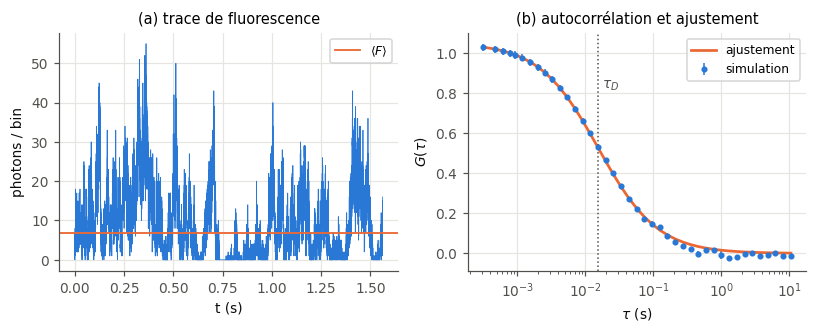

Faisceau     : w0 = 0.25 um -> surface effective pi*w0^2 = 0.196 um2
Boîte        : 4 x 4 um (16 w0), 81 molécules -> 5.1 molécules/um2
Acquisition  : dt = 156 us, T = 15.6 s = 1000 tau_D, 100000 points
Photons      : 100 kHz par molécule -> 6.9 photons/bin en moyenne

N     : 0.95 émetteurs   (simulé : 1.00)
tau_D : 15.6 ms          (attendu : 15.6 ms)
D     : 1.00 um2/s       (simulé : 1.00)


In [18]:
# --- paramètres de référence du simulateur 3 -------------------------------
W0 = 0.25         # rayon du faisceau à 1/e^2, um (valeur calibrée typique)
L3 = 4.0          # côté de la boîte, um = 16 w0 : en dessous, les parois biaisent tau_D
D3 = 1.0          # coefficient de diffusion, um^2/s
N_EFF = 1.0       # émetteurs par surface effective pi*w0^2
CPS = 1e5         # brillance : 100 kHz par molécule au centre du faisceau

# le binning et la durée sont calés sur le temps de résidence attendu :
# 100 points par tau_D pour décrire la décroissance, 1000 tau_D pour la statistique
TAU_D3 = W0**2/(4*D3)
DT3 = TAU_D3/100
T3 = 1000*TAU_D3
n3 = n_particules(N_EFF, L3**2, W0)

tau, G, err, F = fcs(Boite(L3), D3, T3, DT3, n3, Faisceau(W0), n_rep=8, seed=30, cps=CPS)
res = ajuste_fcs(tau, G, W0)
fen = slice(0, 10000)                     # ~100 temps de residence : fenetre representative

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.1))

ax[0].plot(np.arange(10000)*DT3, F[fen], color=CAT[0], lw=.5)
ax[0].axhline(F.mean(), color=CAT[1], lw=1.2, label="$\\langle F \\rangle$")
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("photons / bin")
ax[0].legend()
ax[0].set_title("(a) trace de fluorescence")

ax[1].errorbar(tau, G, err, fmt="o", color=CAT[0], ms=3, lw=1, label="simulation")
ax[1].plot(tau, modele_fcs(tau, 1/res["N"], res["tau_D"]), color=CAT[1], lw=1.8, label="ajustement")
ax[1].axvline(res["tau_D"], color=GRIS, ls=":", lw=1)
ax[1].annotate("$\\tau_D$", (res["tau_D"]*1.15, G.max()*.8), color=GRIS)
ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].legend()
ax[1].set_title("(b) autocorrélation et ajustement")

plt.show()

print("Faisceau     : w0 = %.2f um -> surface effective pi*w0^2 = %.3f um2" % (W0, np.pi*W0**2))
print("Boîte        : %.0f x %.0f um (%.0f w0), %d molécules -> %.1f molécules/um2" % (L3, L3, L3/W0, n3, n3/L3**2))
print("Acquisition  : dt = %.0f us, T = %.1f s = %.0f tau_D, %d points" % (1e6*DT3, T3, T3/TAU_D3, int(T3/DT3)))
print("Photons      : %.0f kHz par molécule -> %.1f photons/bin en moyenne" % (CPS/1e3, F.mean()))
print()
print("N     : %.2f émetteurs   (simulé : %.2f)" % (res["N"], N_EFF))
print("tau_D : %.1f ms          (attendu : %.1f ms)" % (1e3*res["tau_D"], 1e3*TAU_D3))
print("D     : %.2f um2/s       (simulé : %.2f)" % (res["D"], D3))

L'ajustement du modèle théorique sur la courbe expérimentale simulée permet de retrouver les grandeurs fondamentales du système. Le nombre d'émetteurs est $N_{\text{mesuré}} = 0,95\text{ émetteur}$, comprativement à la valeur simulée de $1,00$. Le temps de résidence est $\tau_{D,\text{mesuré}} = 15,6\text{ ms}$, comparativement à la valeur théorique attendue de $\tau_D = 15,625\text{ ms}$. Le coefficient de diffusion est $D_{\text{mesuré}} = 1,00\ \mu\text{m}^2/\text{s}$, comparetivement à la valeur simulée de $1,00\ \mu\text{m}^2/\text{s}$.

Cette mesure de référence illustre que l'amplitude à l'origine $G(0) = 1/N$ est inversement proportionnelle au nombre moyen de molécules $N$ présentes dans le volume focal. Cette amplitude informe uniquement sur la densité. Le temps de demi-décroissance $\tau_D$ mesure la durée moyenne de transit d'une molécule à travers le faisceau. Il dépend uniquement de la cinétique de transport ($D$) et de la taille du faisceau ($w_0$).

### A) Impact du coefficient de diffusion (0,1 à 10 µm²/s)

L'analyse de la fonction d'autocorrélation $G(\tau)$ pour différents coefficients de diffusions, variant de $D = 0,10$ à $10,00\ \mu\text{m}^2/\text{s}$, permet de caractériser la dynamique temporelle associée à la diffusion des molécules dans le volume focal.

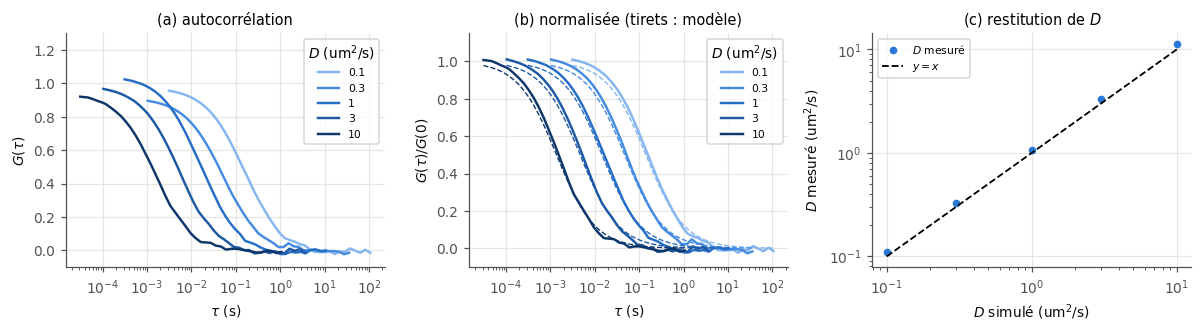

  D simulé   tau_D attendu   tau_D mesuré   D mesuré   N mesuré   dt (us)   T (s)
     0.10        156.25         142.21       0.11       1.02    1562.5   156.2
     0.30         52.08          47.38       0.33       1.09     520.8    52.1
     1.00         15.62          14.64       1.07       0.95     156.2    15.6
     3.00          5.21           4.71       3.32       1.01      52.1     5.2
    10.00          1.56           1.38      11.29       1.05      15.6     1.6


In [19]:
Ds3 = [0.1, 0.3, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
res_D = []

for k, (c, D) in enumerate(zip(seq(len(Ds3)), Ds3)):
    tauD = W0**2/(4*D)
    tau, G, err, _ = fcs(Boite(L3), D, 1000*tauD, tauD/100, n3, Faisceau(W0), n_rep=8, seed=31 + 100*k, cps=CPS)
    r = ajuste_fcs(tau, G, W0)
    res_D.append(r)

    ax[0].plot(tau, G, color=c, lw=1.6, label="%g" % D)
    ax[1].plot(tau, G/G[:3].mean(), color=c, lw=1.6, label="%g" % D)
    ax[1].plot(tau, modele_fcs(tau, 1., r["tau_D"]), color=c, lw=.9, ls="--")

ax[0].set_xscale("log")
ax[0].set_ylim(-0.1, 1.3)
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(title="$D$ (um$^2$/s)", fontsize=7)
ax[0].set_title("(a) autocorrélation")

ax[1].set_xscale("log")
ax[1].set_ylim(-0.1, 1.15)
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)/G(0)$")
ax[1].legend(title="$D$ (um$^2$/s)", fontsize=7)
ax[1].set_title("(b) normalisée (tirets : modèle)")

ax[2].plot(Ds3, [r["D"] for r in res_D], "o", color=CAT[0], label="$D$ mesuré")
ax[2].plot(Ds3, Ds3, "--", color="k", lw=1.2, label="$y = x$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$D$ simulé (um$^2$/s)")
ax[2].set_ylabel("$D$ mesuré (um$^2$/s)")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) restitution de $D$")

plt.show()

print("  D simulé   tau_D attendu   tau_D mesuré   D mesuré   N mesuré   dt (us)   T (s)")

for D, r in zip(Ds3, res_D):
    tauD = W0**2/(4*D)
    print("  %7.2f   %11.2f   %12.2f   %8.2f   %8.2f   %7.1f   %5.1f" % (D, 1e3*tauD, 1e3*r["tau_D"], r["D"], r["N"], 1e6*tauD/100, 1000*tauD))

Pour toutes les valeurs de $D$ simulées, le nombre moyen d'émetteurs extrait de l'amplitude à l'origine ($G(0) = 1/N$) reste pratiquement constant, avec une valeur de $N_{\text{mesuré}} = 1,02 \pm 0,05\text{ émetteur}$. Cela montre que l'amplitude de la courbe d'autocorrélation dépend uniquement du nombre de molécules présentes dans le volume d'observation. La vitesse à laquelle les molécules traversent ce volume n'a pas d'impact sur l'amplitude $G(0)$.

Lorsque le coefficient de diffusion augmente, les molécules traversent le faisceau laser plus rapidement, ce qui réduit le temps de corrélation des fluctuations de fluorescence. L'augmentation de $D$ se traduit par un décalage horizontal de la courbe $G(\tau)$ vers la gauche, sans modifier sa forme globale. Dans le panneau (b), une fois normalisées, les courbes conservent la même forme en $1/(1+\tau/\tau_D)$, que le modèle (courbes en tirets) suit dans les cinq cas.

Les valeurs de $D$ obtenues concordent avec les valeurs simulées, avec une erreur relative inférieure à $7\ %$ sur l'ensemble de la plage étudiée (panneau c).

Un point important à souligner est que, pour analyser correctement des molécules de mobilités très différentes, le pas d'échantillonnage $dt$ et la durée totale d'acquisition $T$ ont été adaptés proportionnellement à $\tau_D$. Par exemple, pour $D = 0,10\ \mu\text{m}^2/\text{s}$, le pas était $dt = 1562,5\ \mu\text{s}$ et $T = 156,2\text{ s}$, alors que pour $D = 10,00\ \mu\text{m}^2/\text{s}$, le pas était de $dt = 15,6\ \mu\text{s}$ et $T = 1,6\text{ s}$. Cette adaptation est importante, car conserver un pas de temps $dt$ trop long pour des molécules à diffusion rapide ($D = 10$) conduirait à un sous-échantillonnage, avec moins de deux points pour décrire $\tau_D$. Les fluctuations rapides seraient alors sous-estimées, ce qui empêcherait une mesure précise de $D$.

### B) Impact de la densité (0,1 à 10 émetteurs par $\pi w_0^2$)

L'analyse de la fonction d'autocorrélation $G(\tau)$ pour des densités variant de $0,1$ à $10,0$ émetteurs par surface effective, soit de $0,5$ à $50,9\text{ molécules}/\mu\text{m}^2$, permet d'étudier l'influence de la densité sur l'amplitude de la fonction d'autocorrélation.

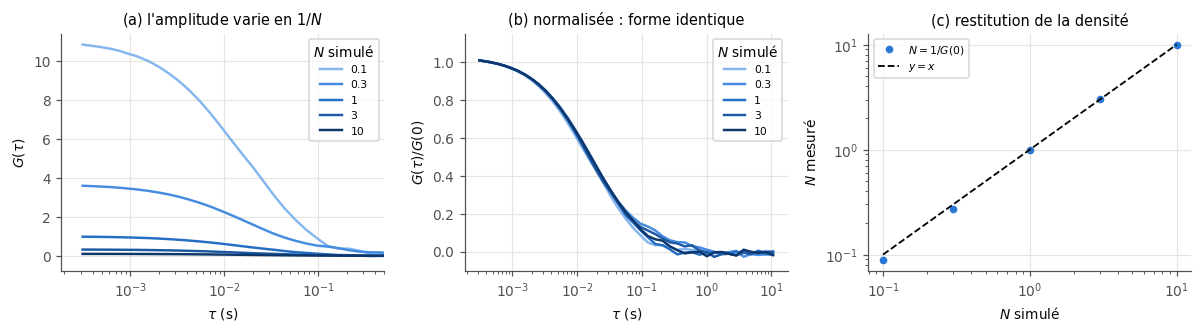

  N simulé   molécules   densité (/um2)   G(0)     N mesuré   tau_D (ms)
     0.10           8             0.5   11.223       0.09         12.7
     0.30          24             1.5    3.669       0.27         15.6
     1.00          81             5.1    1.011       0.99         14.1
     3.00         244            15.2    0.327       3.05         14.3
    10.00         815            50.9    0.100       9.98         14.7


In [20]:
Neffs = [0.1, 0.3, 1.0, 3.0, 10.0]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
res_N = []

for k, (c, Ne) in enumerate(zip(seq(len(Neffs)), Neffs)):
    n = n_particules(Ne, L3**2, W0)
    tau, G, err, _ = fcs(Boite(L3), D3, T3, DT3, n, Faisceau(W0), n_rep=8, seed=32 + 100*k, cps=CPS)
    r = ajuste_fcs(tau, G, W0)
    res_N.append(r)

    ax[0].plot(tau, G, color=c, lw=1.6, label="%g" % Ne)
    ax[1].plot(tau, G/G[:3].mean(), color=c, lw=1.6, label="%g" % Ne)

ax[0].set_xscale("log")
ax[0].set_xlim(None, 0.5)
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(title="$N$ simulé", fontsize=7)
ax[0].set_title("(a) l'amplitude varie en $1/N$")

ax[1].set_xscale("log")
ax[1].set_ylim(-0.1, 1.15)
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)/G(0)$")
ax[1].legend(title="$N$ simulé", fontsize=7)
ax[1].set_title("(b) normalisée : forme identique")

ax[2].plot(Neffs, [r["N"] for r in res_N], "o", color=CAT[0], label="$N = 1/G(0)$")
ax[2].plot(Neffs, Neffs, "--", color="k", lw=1.2, label="$y = x$")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("$N$ simulé")
ax[2].set_ylabel("$N$ mesuré")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) restitution de la densité")

plt.show()

print("  N simulé   molécules   densité (/um2)   G(0)     N mesuré   tau_D (ms)")

for Ne, r in zip(Neffs, res_N):
    n = n_particules(Ne, L3**2, W0)
    print("  %7.2f   %9d   %13.1f   %6.3f   %8.2f   %10.1f" % (Ne, n, n/L3**2, 1/r["N"], r["N"], 1e3*r["tau_D"]))

L'amplitude à l'origine de la courbe d'autocorrélation est inversement proportionnelle au nombre moyen $N$ de particules présentes simultanément dans le volume d'excitation. Plus le nombre de molécules dans le faisceau est faible, plus l'entrée ou la sortie d'une seule molécule produit une variation importante du signal ($\delta F / \langle F \rangle$), et plus l'amplitude de l'autocorrélation est élevée. À l'inverse, à forte concentration, la présence simultanée de nombreuses particules atténue les fluctuations relatives du signal et réduit l'amplitude $G(0)$. Ce phénomène est observable au panneau (a).

Alors que l'amplitude varie de $11,223$ à $0,100$, le temps de résidence mesuré demeure constant à une valeur de $\tau_D \approx 14 \pm 1\text{ ms}$. Au panneau (b), une fois les courbes normalisées par rapport à leur amplitude ($G(\tau)/G(0)$), les cinq courbes se superposent. Ce résultat montre que la concentration influence l'amplitude de la fonction d'autocorrélation, sans modifier le temps de corrélation associé à la diffusion. Les valeurs de densité mesurées suivent la relation $y=x$ sur toute la plage étudiée (panneau c), soit de $0,1$ à $10$ émetteurs par surface effective, correspondant à $0,5$ à $51\text{ molécules}/\mu\text{m}^2$.

Les deux extrémités de la plage de densité étudiée présentent certaines difficultés. À $N = 10$, l'amplitude $G(0)$ n'est plus que de $0,1$. Les fluctuations relatives sont alors faibles et la courbe atteint rapidement le niveau de bruit, après quelques $\tau_D$, ce qui limite la partie de la courbe exploitable dans le panneau (a). À l'inverse, à $N = 0,1$, l'amplitude est élevée et facilement mesurable, mais les passages de molécules sont plus rares, ce qui nécessite une durée d'acquisition suffisamment longue pour obtenir un nombre d'événements représentatif. Ainsi, les conditions autour de $N \sim 1$ offrent un compromis entre l'amplitude des fluctuations et le nombre d'événements observés.

<!--
$N = 0{,}10\text{ émetteur}$ (8 mol.) : $G(0) = 11{,}223 \implies N_{\text{mesuré}} = 0{,}09$
$N = 0{,}30\text{ émetteur}$ (24 mol.) : $G(0) = 3{,}669 \implies N_{\text{mesuré}} = 0{,}27$
$N = 1{,}00\text{ émetteur}$ (81 mol.) : $G(0) = 1{,}011 \implies N_{\text{mesuré}} = 0{,}99$
$N = 3{,}00\text{ émetteurs}$ (244 mol.) : $G(0) = 0{,}327 \implies N_{\text{mesuré}} = 3{,}05$
$N = 10{,}00\text{ émetteurs}$ (815 mol.) : $G(0) = 0{,}100 \implies N_{\text{mesuré}} = 9{,}98$ -->

### C) Deux populations de coefficients de diffusion différents

Deux populations seront inclusent, une avec des particules lentes présentant un coefficient de diffusion $D_{\text{lent}} = 0,5\ \mu\text{m}^2/\text{s}$) et une seconde avec des particules rapides, soit $D_{\text{rapide}} = 10,0\ \mu\text{m}^2/\text{s}$. Les deux populations diffusent indépendamment, donc leurs fluctuations ne sont pas corrélées entre elles. Il est alors nécessaire de calculer une autocorrélation par population, avec `fcs`, qui seront ensuite combinées. La combinaison n'est pas simplement une sommation. Chaque population contribue au signal total selon sa fraction d'intensité $f_i$. Comme $G$ est normalisée par le carré de l'intensité moyenne, ces fractions apparaissent au carré :
$$G(\tau) = f_A^2\,G_A(\tau) + f_B^2\,G_B(\tau),
\qquad f_i = \frac{\langle F_i\rangle}{\langle F_A\rangle + \langle F_B\rangle}$$

À brillance égale, $f_i$ est simplement la fraction du nombre de molécules. Il sera vérifié que cette combinaison permet effectivement de retrouver $G(0) = 1/(N_A + N_B)$ et donc que les amplitudes s'additionnent en concentration, et non en corrélation.

Finalement, pour caractériser deux populations séparées d'un facteur 20 en vitesse de diffusion, la fenêtre d'acquisition doit couvrir simultanément les deux échelles de temps. Un pas de temps court ($dt = 31,2\ \mu\text{s}$) garantit 50 points de mesure sur le temps de transit rapide ($\tau_{D,\text{rapide}} = 1,56\text{ ms}$), permettant d'éviter de sous-échantillonner la population rapide. Une durée totale longue ($T = 31,2\text{ s}$) permet quant à elle de couvrir exactement 1000 fois le temps de transit lent ($\tau_{D,\text{lent}} = 31,25\text{ ms}$), ce qui permet de suivre la fonction d'autocorrélation jusqu'à son retour à la ligne de base. Cela permet d'obtenir $1,000,000$ points pour l'acquisition totale.


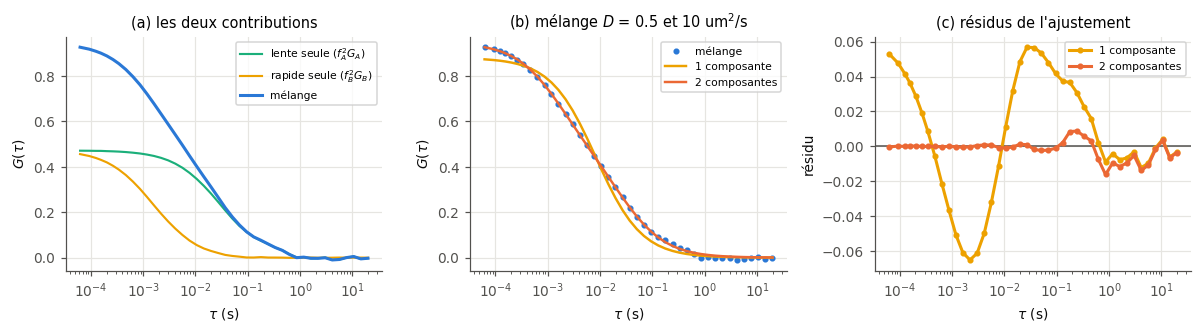

Echantillonnage : dt = 31.2 us (rapide), T = 31.2 s (lente), 1000000 points
Amplitudes      : G_A(0) = 1.88 -> N_A = 0.53  |  G_B(0) = 1.79 -> N_B = 0.56
Melange         : G(0) = 0.917 -> N = 1.09  (attendu 1.00)

1 composante    : N = 1.14   D = 1.85 um2/s  (aucune des deux valeurs simulées)
2 composantes   : N = 1.06   D_lent = 0.56 (0.5)   D_rapide = 10.1 (10.0)   fraction lente = 0.50 (0.50)


In [29]:
DA = 0.5     # coefficient de diffusion de la population lente, um^2/s
DB = 10.0    # coefficient de diffusion de la population rapide, um^2/s
NE = 0.5     # densité de chaque population, émetteurs par surface effective
nA = n_particules(NE, L3**2, W0)
nB = n_particules(NE, L3**2, W0)

DT_MIX = W0**2/(4*DB)/50        # 50 points par tau_D de la population rapide
T_MIX = 1000*W0**2/(4*DA)       # 1000 tau_D de la population lente

# une autocorrelation par population, puis combinaison ponderee
tau, GA, _, _ = fcs(Boite(L3), DA, T_MIX, DT_MIX, nA, Faisceau(W0), n_rep=8, seed=33, cps=CPS)
tau, GB, _, _ = fcs(Boite(L3), DB, T_MIX, DT_MIX, nB, Faisceau(W0), n_rep=8, seed=77, cps=CPS)

fA = nA/(nA + nB)               # fractions d'intensite (brillance identique)
fB = nB/(nA + nB)
G2 = fA**2*GA + fB**2*GB

r1 = ajuste_fcs(tau, G2, W0)
p, _ = curve_fit(modele_fcs2, tau, G2, maxfev=40000, p0=[G2[:3].mean(), W0**2/(4*DA), W0**2/(4*DB), .5])

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))

ax[0].plot(tau, fA**2*GA, color=CAT[2], lw=1.4, label="lente seule ($f_A^2 G_A$)")
ax[0].plot(tau, fB**2*GB, color=CAT[3], lw=1.4, label="rapide seule ($f_B^2 G_B$)")
ax[0].plot(tau, G2, color=CAT[0], lw=2, label="mélange")
ax[0].set_xscale("log")
ax[0].set_xlabel("$\\tau$ (s)")
ax[0].set_ylabel("$G(\\tau)$")
ax[0].legend(fontsize=7)
ax[0].set_title("(a) les deux contributions")

ax[1].plot(tau, G2, "o", color=CAT[0], ms=3, label="mélange")
ax[1].plot(tau, modele_fcs(tau, 1/r1["N"], r1["tau_D"]), color=CAT[3], lw=1.6, label="1 composante")
ax[1].plot(tau, modele_fcs2(tau, *p), color=CAT[1], lw=1.6, label="2 composantes")
ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].legend(fontsize=7)
ax[1].set_title("(b) mélange $D$ = %g et %g um$^2$/s" % (DA, DB))

ax[2].axhline(0, color=GRIS, lw=1)
ax[2].plot(tau, G2 - modele_fcs(tau, 1/r1["N"], r1["tau_D"]), "o-", color=CAT[3], ms=3, label="1 composante")
ax[2].plot(tau, G2 - modele_fcs2(tau, *p), "o-", color=CAT[1], ms=3, label="2 composantes")
ax[2].set_xscale("log")
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("résidu")
ax[2].legend(fontsize=7)
ax[2].set_title("(c) résidus de l'ajustement")

plt.show()

print("Echantillonnage : dt = %.1f us (rapide), T = %.1f s (lente), %d points" % (1e6*DT_MIX, T_MIX, int(T_MIX/DT_MIX)))
print("Amplitudes      : G_A(0) = %.2f -> N_A = %.2f  |  G_B(0) = %.2f -> N_B = %.2f" % (GA[:3].mean(), 1/GA[:3].mean(), GB[:3].mean(), 1/GB[:3].mean()))
print("Melange         : G(0) = %.3f -> N = %.2f  (attendu %.2f)" % (G2[:3].mean(), 1/G2[:3].mean(), 2*NE))
print()
print("1 composante    : N = %.2f   D = %.2f um2/s  (aucune des deux valeurs simulées)" % (r1["N"], r1["D"]))
print("2 composantes   : N = %.2f   D_lent = %.2f (%.1f)   D_rapide = %.1f (%.1f)   fraction lente = %.2f (0.50)" % (1/p[0], W0**2/(4*p[1]), DA, W0**2/(4*p[2]), DB, p[3]))

Le mélange produit une décroissance en deux marches (panneau a), une par population. Pour la population A, celle lente, une amplitude $G_A(0) = 1,88$ est obtenue, ce qui représente $N_A = 0,53\text{ émetteur}$. Pour la population B, celle rapide, une amplitude $G_B(0) = 1,79$ est obtenue, ce qui représente $N_B = 0,56\text{ émetteur}$. Pour le mélange des deux espèces, l'amplitude expérimentale s'élève à $G(0) = 0,917$, ce qui donne un nombre total d'émetteurs de $N_{\text{mélange}} = 1,09\text{ émetteurs}$. Ce résultat correspond exactement la somme des deux populations virtuelles ($N_A + N_B = 0,53 + 0,56 = 1,09$, pour une valeur théorique attendue de $1,00$). Les amplitudes s'additionnent donc effectivement en concentration.

Si la courbe d'autocorrélation du mélange est ajustée avec un modèle à une seule composante (diffusion libre simple), le résultat obtenu est $N = 1,14$ et $D = 1,85\ \mu\text{m}^2/\text{s}$. La valeur du coefficient de diffusion extraite ne correspond à aucune des deux populations réelles (ni $0,5$, ni $10,0\ \mu\text{m}^2/\text{s}$). Le modèle à une seule composante cherche à décrire les deux populations par une seule valeur de diffusion intermédiaire, ce qui ne permet pas de représenter correctement les deux régimes de la courbe. Cela se traduit par un résidu de l'ajustement en forme de S, illustré au panneau (c), soulignant le manque d'une composante.

En utilisant la fonction d'autocorrélation bicomposante à deux temps de résidence (Yu et al., 2021) : 
$$G(\tau) = G(0) \left[ f_{\text{lent}} \frac{1}{1 + \tau/\tau_{D,\text{lent}}} + (1 - f_{\text{lent}}) \frac{1}{1 + \tau/\tau_{D,\text{rapide}}} \right],$$
il est possible de retrouver $D_{\text{lent}} = 0,56\ \mu\text{m}^2/\text{s}$ et $f_{\text{lent}} = 0{,}50$, ainsi que $D_{\text{rapide}} = 10,1\ \mu\text{m}^2/\text{s}$. Les valeurs réelles simulées étaient $0,50\ \mu\text{m}^2/\text{s}$, $0,50$ et $10,0\ \mu\text{m}^2/\text{s}$ respectivement. Un nombre total de particules de $N = 1,06$ a également été retrouvé. Au panneau (c), un résidu plat est retrouvé, les écarts relatifs sont de 1% pour la composante rapide, 12% pour la composante lente et 0% sur la proportion, illustrant la validité du modèle bicomposante.

L'analyse FCS permet ainsi de résoudre avec une très grande précision un mélange de populations à condition que le rapport des coefficients de diffusion soit d'au moins un facteur 5 à 10 (ici $D_{\text{rapide}}/D_{\text{lent}} = 20$) et que la fenêtre d'échantillonnage temporel couvre simultanément les deux régimes de temps. Il faut également qu'un modèle théorique bicomposante soit utilisé lors de la régression.

### D) Bruit de détection

La trace porte déjà le bruit de grenaille, inévitable, lié au comptage des photons. À cela s'ajoute un bruit de fond parasite. Ce fond est tiré dans une loi de Poisson permet de garder un entier positif et un bruit blanc puisque chaque bin est tiré indépendamment. La trajectoire des molécules est la même d'un niveau à l'autre, seule la graine du fond change, avec `seed_bruit = 100*k`.

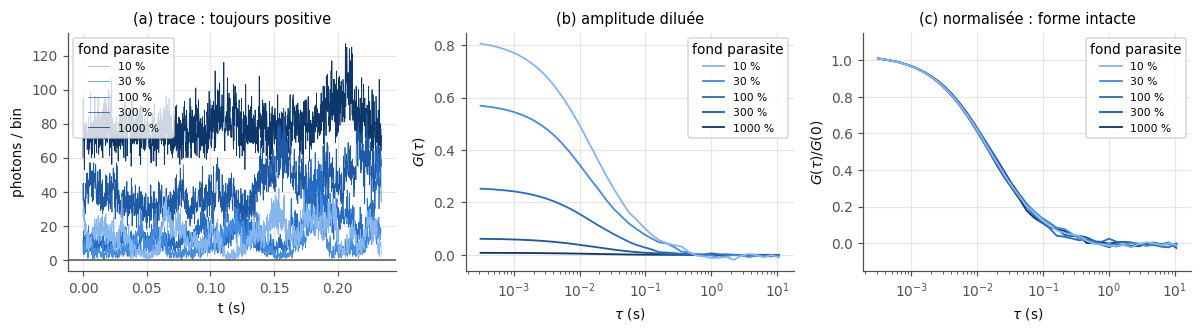

  fond   min(F)   <F>    G(0)   G(0) attendu   tau_D (ms)   N mesuré   N corrigé
    10 %       0    8.9   0.798          0.660        14.5       1.21        1.00
    30 %       0   10.9   0.564          0.472        14.4       1.71        1.01
   100 %       0   14.0   0.250          0.200        14.2       3.84        0.96
   300 %       9   34.9   0.061          0.050        15.4      15.96        1.00
  1000 %      40   80.6   0.008          0.007        13.6     126.71        1.05


In [ ]:
niveaux = [0.1, 0.3, 1.0, 3.0, 10.0]
fen = slice(0, 1500)
t_fen = np.arange(1500)*DT3

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
couleurs = seq(len(niveaux))
res_bg = []

for k in range(len(niveaux) - 1, -1, -1):
    fond = niveaux[k]
    tau, G, err, F = fcs(Boite(L3), D3, T3, DT3, n3, Faisceau(W0), n_rep=10, seed=34 + 100*k, cps=CPS, bruit=fond, seed_bruit=100*k)
    r = ajuste_fcs(tau, G, W0)
    res_bg.append((fond, F.min(), F.mean(), G[:3].mean(), r))
    lab = "%.0f %%" % (100*fond)
    ax[0].plot(t_fen, F[fen], color=couleurs[k], lw=.5, label=lab)
    ax[1].plot(tau, G, color=couleurs[k], lw=1.2, label=lab)
    ax[2].plot(tau, G/G[:3].mean(), color=couleurs[k], lw=1.2, label=lab)

res_bg.reverse()

for a_ in ax:
    poignees, etiquettes = a_.get_legend_handles_labels()
    a_.legend(poignees[::-1], etiquettes[::-1], title="fond parasite", fontsize=7)

ax[0].axhline(0, color=GRIS, lw=1)
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("photons / bin")
ax[0].set_title("(a) trace : toujours positive")

ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].set_title("(b) amplitude diluée")

ax[2].set_xscale("log")
ax[2].set_ylim(-0.15, 1.15)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("$G(\\tau)/G(0)$")
ax[2].set_title("(c) normalisée : forme intacte")

plt.show()

print("  fond   min(F)   <F>    G(0)   G(0) attendu   tau_D (ms)   N mesuré   N corrigé")

for fond, mini, moy, g0, r in res_bg:
    attendu = res_bg[0][3]/(1 + fond)**2
    print("  %4.0f %%  %6.0f  %5.1f  %6.3f  %13.3f  %10.1f   %8.2f   %9.2f" % (100*fond, mini, moy, g0, attendu, 1e3*r["tau_D"], r["N"], r["N"]/(1 + fond)**2))

L'analyse de la trace de fluorescence et des fonctions d'autocorrélation en présence de niveaux croissants de bruit de fond parasite (de 10 % à 1000 % du signal moyen) montre que la cinétique de transport est préservée, tandis que l'amplitude de l'autocorrélation est systématiquement biaisée.

<div align="center">

**Tableau 1 —** Influence du fond fluorescent sur les paramètres d'analyse FCS.

| Fond | $\min(F)$ | $\langle F\rangle$ | $G(0)$ | $\tau_D$ (ms) | $N_{\mathrm{mesuré}}$ | $N_{\mathrm{corrigé}}$ |
|:----:|:---------:|:------------------:|:-----:|:------------:|:---------------------:|:-----------------------:|
| 10 % | 0 | 8,9 | 0,798 | 14,5 | 1,21 | 1,00 |
| 30 % | 0 | 10,9 | 0,564 | 14,4 | 1,71 | 1,01 |
| 100 % | 0 | 14,0 | 0,250 | 14,2 | 3,84 | 0,96 |
| 300 % | 9 | 34,9 | 0,061 | 15,4 | 15,96 | 1,00 |
| 1000 % | 40 | 80,6 | 0,008 | 13,6 | 13,6 | 1,05 |


</div>

Le bruit de fond est constitué de coups indépendants d'un intervalle de temps à l'autre. Ce bruit est temporellement décorrélé (bruit blanc), il n'apporte de corrélation qu'au retard nul ($\tau = 0$), point qui est exclu lors de l'ajustement. Les résultats de la simulation confirment cette propriété. En effet, sur l'ensemble de la gamme (jusqu'à un fond 10 fois supérieur au signal fluorescent), le temps de transit mesuré reste stable à $\tau_D \approx 14,4 \pm 0,7\text{ ms}$. Une fois les courbes normalisées par leur propre amplitude ($G(\tau)/G(0)$), elles se superposent exactement (panneau (c)). Le coefficient de diffusion $D$ n'est donc pas influencé par le bruit de fond.

Comme le fond parasite augmente l'intensité moyenne collectée ($\langle F \rangle = \langle F_{\text{signal}} \rangle + \langle F_{\text{fond}} \rangle$) sans apporter de fluctuations corrélées, il réduit les variations relatives de fluorescence $\delta F / \langle F \rangle$. L'amplitude mesurée à l'origine décroît selon la loi de dilution quadratique théorique (Yu et al., 2021) : 
$$G_{\text{mesuré}}(0) = \left( \frac{\langle F_{\text{signal}} \rangle}{\langle F_{\text{signal}} \rangle + \langle F_{\text{fond}} \rangle} \right)^2 G_{\text{vrai}}(0) = \frac{G_{\text{vrai}}(0)}{(1 + f)^2}$$
où $f = \frac{\langle F_{\text{fond}} \rangle}{\langle F_{\text{signal}} \rangle}$ représente la fraction de fond parasite.

Sans correction, le nombre d'émetteurs extrait ($N_{\text{mesuré}} = 1/G(0)$) augmente de manière quadratique avec le fond (panneau (b)). Par exemple, pour un bruit de fond de 10 %, $N_{\text{mesuré}} = 1,21$, pour un fond de 100 \%, $N_{\text{mesuré}} = 3,84$, (surestimé d'un facteur 4), finalement pour un fond de 1000 %, $N_{\text{mesuré}} = 126,71$ (surestimé d'un facteur 121). Ce biais sur l'amplitude n'étant pas une dégradation aléatoire mais une atténuation déterministe, il est possible de le corriger exactement si le niveau de fond moyen est mesuré indépendamment. En appliquant la formule de correction : 
$$N_{\text{corrigé}} = \frac{N_{\text{mesuré}}}{(1 + f)^2},$$
on retrouve la densité réelle simulée avec une exactitude pour tous les niveaux de bruit de $N_{\text{corrigé}} = 1,00 \pm 0,03\text{ émetteur} \quad (\text{valeur réelle simulée : } 1,00)$.

En conclusion, le fond doit être mesuré séparément afin de corriger la concentration, alors qu’aucune correction n’est nécessaire pour le temps de résidence. De plus, le comptage reste positif partout, comme l’indique la colonne $\min(F)$, ce qui confirme que la loi de Poisson constitue un modèle de bruit approprié, contrairement à un bruit gaussien additif qui pourrait produire des comptages négatifs.

### E) Durée de l'acquisition

Une seule acquisition, sans bruit blanc ajouté et sans moyennage, est effectuée par durée. La seule variable est le nombre de temps de résidence contenus dans la trace, $T/\tau_D$.

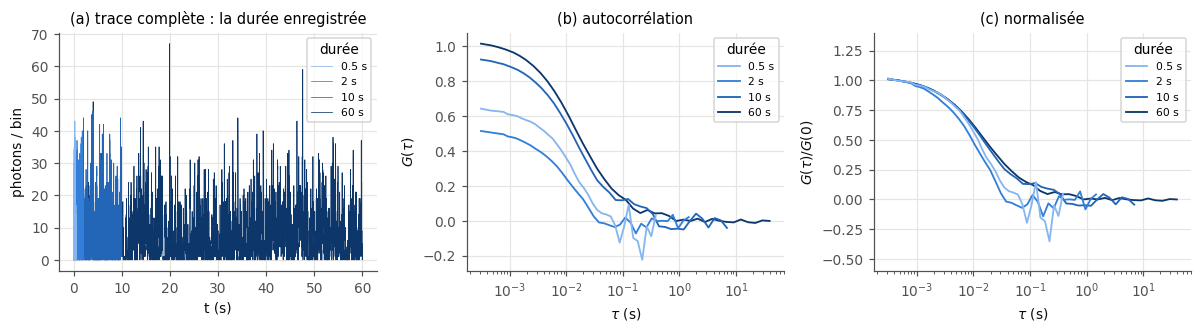

  durée (s)   T/tau_D   points    G(0)   tau_D (ms)
       0.5        32     3201   0.633         7.9
       2.0       128    12801   0.506         6.1
      10.0       640    64001   0.914        13.2
      60.0      3840   384001   1.005        14.6


In [ ]:
durees3 = [0.5, 2., 10., 60.]
res_T = []

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
couleurs = seq(len(durees3))

for k in range(len(durees3) - 1, -1, -1):
    T = durees3[k]
    tau, G, err, F = fcs(Boite(L3), D3, T, DT3, n3, Faisceau(W0), seed=35, cps=CPS)
    res_T.append((T, len(F), G[:3].mean(), ajuste_fcs(tau, G, W0)))
    pas = max(1, len(F)//3000)
    lab = "%g s" % T
    ax[0].plot(np.arange(len(F))[::pas]*DT3, F[::pas], color=couleurs[k], lw=.5, label=lab)
    ax[1].plot(tau, G, color=couleurs[k], lw=1.2, label=lab)
    ax[2].plot(tau, G/G[:3].mean(), color=couleurs[k], lw=1.2, label=lab)

res_T.reverse()

for a_ in ax:
    poignees, etiquettes = a_.get_legend_handles_labels()
    a_.legend(poignees[::-1], etiquettes[::-1], title="durée", fontsize=7)

ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("photons / bin")
ax[0].set_title("(a) trace complète : la durée enregistrée")

ax[1].set_xscale("log")
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$G(\\tau)$")
ax[1].set_title("(b) autocorrélation")

ax[2].set_xscale("log")
ax[2].set_ylim(-0.6, 1.4)
ax[2].set_xlabel("$\\tau$ (s)")
ax[2].set_ylabel("$G(\\tau)/G(0)$")
ax[2].set_title("(c) normalisée")

plt.show()

print("  durée (s)   T/tau_D   points    G(0)   tau_D (ms)")

for T, npts, g0, r in res_T:
    print("  %8.1f  %8.0f   %6d  %6.3f  %10.1f" % (T, T/TAU_D3, npts, g0, 1e3*r["tau_D"]))

L'analyse de l'effet de la durée de mesure $T$ (exprimée en nombre de temps de résidence $T/\tau_D$) révèle qu'une durée d'acquisition trop courte fausse simultanément l'amplitude $G(0)$ et la cinétique de transit $\tau_D$. Le panneau (a) montre la trace complète de chaque acquisition et le panneau (b) l'autocorrélation qui en découle.

<div align="center">

**Tableau 1 —** Influence de la durée de simulation sur les paramètres d'analyse FCS.

| Durée | $T/\tau_D$ | Points | $G(0)$ | $\tau_D$ |
|---|---|---|---|---|
| 0,5 s | 32 | 3 201 | 0,633 | 7,9 ms |
| 2 s | 128 | 12 801 | 0,506 | 6,1 ms |
| 10 s | 640 | 64 001 | 0,914 | 13,2 ms |
| 60 s | 3 840 | 384 001 | 1,005 | 14,6 ms |

</div>

Contrairement au bruit de fond, une acquisition de durée insuffisante déforme l'entièreté de la courbe d'autocorrélation $G(\tau)$. Par exemple, pour une durée de $T = 0,5\text{ s}$, $G(0) = 0,633$ (au lieu de $1,00$) et $\tau_D = 7,9\text{ ms}$ (au lieu de $15,6\text{ ms}$). Lorsque les fonctions d'autocorrélation sont normalisées ($G(\tau)/G(0)$), les courbes associées aux temps d'acquisition courts décroissent trop rapidement et atteignent des valeurs négatives, jusqu'à $-0,35$, ce qui est physiquement impossible pour une diffusion brownienne pure.

Ce biais ne provient pas du détecteur ni du bruit photonique, mais de la statistique d'échantillonnage. Il y a une mauvaise estimation de la moyenne temporelle ($\langle F \rangle$). Une trace de moins de 2 secondes ne contient que quelques dizaines de passages de particules. La moyenne de l'intensité $\langle F \rangle$, servant au dénominateur de normalisation de $G(\tau)$, n'a pas convergé. Aux délais temporels $\tau$ plus élevés, le nombre de paires de points indépendants disponibles pour calculer la corrélation devient trop faible, ce qui fausse la ligne de base.

Lorsque la durée de simulation augmente, les paramètres extraits convergent avec précision vers les valeurs réelles du système. Par exemple, pour une durée de $T = 60{,}0\text{ s}$, $G(0) = 1,005, ce qui permet d'obtenir $N = 0,995$ et $\tau_D = 14,6\text{ ms}$. Ce qui limite une mesure de FCS n'est pas la qualité du détecteur, mais plutôt le
nombre d'événements enregistrés. Ainsi, pour obtenir un ajustement stable et non biaisé sans artefact de tronquage, l'expérience doit couvrir au minimum $10^3$ temps de résidence (soit $T \ge 1000 \, \tau_D$).

# Références

Toute la théorie utilisée ci-dessus provient des trois articles du cours correspondant aux trois
simulateurs.

1. **X. Michalet**, *Mean square displacement analysis of single-particle trajectories with
   localization error: Brownian motion in an isotropic medium*, Phys. Rev. E **82**, 041914 (2010).
   Simulateur 1 : estimateur de MSD (éq. 7), MSD en présence d'erreur de localisation et de temps de
   pose (éq. 14-15), extraction de $D$ et $\sigma$ (éq. 17-18), incertitude de localisation statique
   et dynamique (éq. 2 et 4), nombre optimal de points d'ajustement (éq. 30).

2. **A. K. Kenworthy**, *What's past is prologue: FRAP keeps delivering 50 years later*,
   Biophys. J. **122**, 3577 (2023). Simulateur 2 : les deux informations portées par une courbe de
   FRAP ($t_{1/2}$ et fraction mobile), nécessité d'un modèle adapté à la géométrie et à la taille
   de la zone blanchie, aux conditions aux limites et à la dimensionnalité du retour, hypothèses de
   base de la technique.

3. **L. Yu, Y. Lei, Y. Ma, M. Liu, J. Zheng, D. Dan, P. Gao**, *A comprehensive review of
   fluorescence correlation spectroscopy*, Front. Phys. **9**, 644450 (2021). Simulateur 3 :
   définition de $G(\tau)$ (éq. 1), modèle de diffusion et sa réduction au cas 2D (éq. 2),
   $\tau_D = r_0^2/4D$ (rayon noté $w_0$ ici), algorithme multi-tau, ordres de grandeur du tableau 1.
